# Empirical Validation of Theory

---

## Imports

In [87]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy

from networks.BP_network import BP_network
from networks.EWC_network import EWC_network
from networks.EFC_network import EFC_network
from networks.EHC_network import EHC_network
from src.dataloaders import ClassILMNIST2Task
from src.utils import dotdict

from tqdm import tqdm
import os
from sklearn.decomposition import PCA
import pickle

## Config

In [112]:
config = {
    "lr": 2e-4,
    "batch_size": 256,
    "epochs": 20,
    "mode": "di",  # or "di"
    "num_workers": 0,
    "loss_fn": "ce", # "mse"
    "optimizer": "Adam",
    "scheduler": "CosineAnnealingLR",
    "device": "cpu" if torch.cuda.is_available() else "cpu",
    "output_dir": "./outputs",
    "seed": 0,
    "target_lr": 2e-2, # needs to be < time_constant_ratio
    "alpha_di": 0.0017,
    "alpha_I": 0.0017,
    "tau": 0.032,
    "dt_di": 0.02,
    "psi_lr": 0.1,
    "alpha_psi": 0.0,
    "time_constant_ratio": 0.2, # this param can be merged with dt_di
    "tmax_di": 500,
    "k_p": 2.0,
    "eps": 1e-4, # there is an interplay between dt_di and eps and between target_lr and eps
    "save": False,
    "importance_ewc": 4.0, # ewc params
    "beta_efc": 1e-1, # efc params
    "flatten_imgs": True,
    "setting": "classIL2task", # domainIL, taskIL, classIL5task, classIL2task
    "peak": False, # saves the peak model based on cumulative accuracy and restores it after each task
    "layers": [784, 64, 64, 10],
    "num_tasks": 2,
    "classes_per_task": 5,
}

config = dotdict(config)
torch.set_default_device(config.device)
torch.manual_seed(config.seed)
np.random.seed(config.seed)

## Dataloaders – Class-IL 2-task Split-MNIST

In [3]:
dataloader = ClassILMNIST2Task(config)

train_loader_A, test_loader_A = dataloader.get_dataloaders(task_id=0)
train_loader_B, test_loader_B = dataloader.get_dataloaders(task_id=1)

print(f"Task A: {len(train_loader_A.dataset)} train, {len(test_loader_A.dataset)} test")
print(f"Task B: {len(train_loader_B.dataset)} train, {len(test_loader_B.dataset)} test_only")

Task A: 30596 train, 5139 test
Task B: 29404 train, 10000 test_only


## Train Task A on BP_network

In [4]:
def evaluate(net, loader, task_id, task_classes):
    net.eval()
    correct = total = 0.0
    total_loss = 0.0
    task_set = set(range(task_classes[0], task_classes[1] + 1))
    criterion = net.loss_fn  # CE or MSE

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(config.device), y.to(config.device)
            net.task_id = task_id
            out = net(x)
            true_labels = y.argmax(1)

            mask = torch.isin(true_labels, torch.tensor(list(task_set), device=config.device))
            if not mask.any():
                continue

            out = out[mask]
            y = y[mask]
            true_labels = true_labels[mask]

            start_idx = task_classes[0]
            pred_rel = out[:, start_idx:task_classes[1]+1].argmax(1)
            pred_abs = pred_rel + start_idx

            correct += (pred_abs == true_labels).sum().item()
            total += true_labels.size(0)
            total_loss += criterion(out[:, :task_classes[1]+1], y.argmax(1)).item() * true_labels.size(0)

    acc = correct / total if total else 0.0
    loss = total_loss / total if total else 0.0
    return acc, loss

In [5]:
bp_net_A = BP_network(config).to(config.device)
bp_net_A.task_id = 0
optimizer = optim.Adam(bp_net_A.parameters(), lr=config.lr)

bp_net_A.train()

for epoch in range(config.epochs):
    pbar = tqdm(total=len(train_loader_A), desc="BP (Task A)", unit="epoch", leave=True)
    for x, y in train_loader_A:
        x, y = x.to(config.device), y.to(config.device)

        optimizer.zero_grad()
        y_hat = bp_net_A(x)
        _ = bp_net_A.calculate_loss(y_hat, y.argmax(dim=1))
        bp_net_A.backward(y)          # BP-specific backward
        optimizer.step()

        pbar.update(1)

    # Train accuracy on Task A
    test_acc_A, _ = evaluate(bp_net_A, test_loader_A, task_id=0, task_classes=[0, 4])
    test_acc_B, _ = evaluate(bp_net_A, test_loader_B, task_id=1, task_classes=[5, 9])
    combined_test_acc, _ = evaluate(bp_net_A, test_loader_B, task_id=1, task_classes=[0, 9])  # all 10 classes are present

    # Update the progress-bar postfix
    pbar.set_postfix({
        "Test A" : f"{test_acc_A:.3f}",
        "Test B" : f"{test_acc_B:.3f}",
        "Comb"   : f"{combined_test_acc:.3f}"
    })

    pbar.close()

BP (Task A): 100%|██████████| 120/120 [00:00<00:00, 388.77epoch/s, Test A=0.986, Test B=0.271, Comb=0.507]


## Copy Weights to All Methods & Reset Optimizers

In [107]:
config.epochs=3

In [113]:
def copy_weights(src_net, dst_net):
    dst_net.load_state_dict(deepcopy(src_net.state_dict()))

# Create all networks
ewc_net = EWC_network(config).to(config.device)
efc_net = EFC_network(config).to(config.device)
bp_net = BP_network(config).to(config.device)
# ehc_net = EHC_network(config).to(config.device)

# Set to train mode
ewc_net.train()
efc_net.train()
bp_net.train()
# ehc_net.train()

nets = {
    'bp': bp_net,
    'ewc': ewc_net,
    'efc': efc_net,
    # 'ehc': ehc_net
}

# Reset task IDs
ewc_net.task_id = 0
efc_net.task_id = 0
bp_net.task_id = 0
# ehc_net.task_id = 0

# Copy Task A weights
copy_weights(bp_net_A, ewc_net)
copy_weights(bp_net_A, efc_net)
copy_weights(bp_net_A, bp_net)
# copy_weights(bp_net_A, ehc_net)

# Reset optimizers
optimizers = {
    'ewc': optim.Adam(ewc_net.parameters(), lr=config.lr),
    'efc': optim.Adam(efc_net.parameters(), lr=config.lr),
    'bp':  optim.Adam(bp_net.parameters(), lr=config.lr),
    # 'ehc': optim.SGD(ehc_net.parameters(), lr=config.lr),
}

print("Weights copied, optimizers reset.")

Weights copied, optimizers reset.


## Compute Fisher & Hessian

In [114]:
ewc_net.complete_task(train_loader_A)
efc_net.complete_task(train_loader_A)
bp_net.complete_task(train_loader_A)
# ehc_net.complete_task(train_loader_A)

fisher_A = ewc_net._fisher
# hessian_A = ehc_net._hessian

ewc_net.task_id = 1
efc_net.task_id = 1
bp_net.task_id = 1
# ehc_net.task_id = 1

## Train and evaluate on Task B

In [115]:
weight_deltas = {name: [] for name in nets}  # List of dicts {param_name: delta_tensor} for first 5 batches
acc_logs = {name: {'acc_A': [], 'acc_B': [], 'combined': []} for name in nets}
loss_logs = {name: {'loss_A': [], 'loss_B': [], 'combined': []} for name in nets} 

for name, net in nets.items():
    opt = optimizers[name]
    net.train()
    batch_idx = 0
    old_params = {n: p.clone().detach() for n, p in net.named_parameters() if p.requires_grad}

    for epoch in range(config.epochs):
        pbar = tqdm(total=len(train_loader_B), desc=f"{name} (Task B)", unit="epoch", leave=True)
        for x, y in train_loader_B:
            x, y = x.to(config.device), y.to(config.device)

            opt.zero_grad()
            y_hat = net(x)
            _ = net.calculate_loss(y_hat, y.argmax(dim=1))
            net.backward(y)
            opt.step()

            pbar.update(1)
            batch_idx += 1

            if batch_idx % 10 == 0:
                (acc_A, loss_A)       = evaluate(net, test_loader_A, task_id=0, task_classes=[0, 4])
                (acc_B, loss_B)       = evaluate(net, test_loader_B, task_id=1, task_classes=[5, 9])
                (acc_comb, loss_comb) = evaluate(net, test_loader_B, task_id=1, task_classes=[0, 9])

                acc_logs[name]['acc_A'].append(acc_A)
                acc_logs[name]['acc_B'].append(acc_B)
                acc_logs[name]['combined'].append(acc_comb)

                loss_logs[name]['loss_A'].append(loss_A)
                loss_logs[name]['loss_B'].append(loss_B)
                loss_logs[name]['combined'].append(loss_comb)

                pbar.set_postfix({
                    'A': f'{acc_A:.3f}',
                    'B': f'{acc_B:.3f}',
                    'C': f'{acc_comb:.3f}',
                    'LA': f'{loss_A:.3f}',
                    'LB': f'{loss_B:.3f}',
                    'LC': f'{loss_comb:.3f}'
                })
                
                if batch_idx != 0:
                    delta = {n: p - old_params[n] for n, p in net.named_parameters() if p.requires_grad}
                    weight_deltas[name].append(delta)
                    old_params = {n: p.clone().detach() for n, p in net.named_parameters() if p.requires_grad}

        pbar.close()

efc (Task B): 100%|██████████| 115/115 [00:32<00:00,  3.58epoch/s, A=0.968, B=0.937, C=0.702, LA=0.168, LB=0.437, LC=0.829]


In [93]:
## EFC hyperparams

In [97]:
## Hyperparameter optimization for EFC on Task B (with full continual learning evaluation)

from itertools import product
from copy import deepcopy

# --- Hyperparameter grid ---
lr_vals      = [1e-4, 5e-4, 1e-3]
target_vals  = [1.0, 5e-1, 1e-1, 5e-2, 1e-2]
beta_vals    = [0.0, 0.001, 0.005, 0.01, 0.05]
config.epochs    = 2

# Containers for structured logging (easy plotting later)
acc_logs  = {}   # acc_logs[key]['A'] → list of acc_A over logging steps
loss_logs = {}   # loss_logs[key]['A'] → list of loss_A

# --- Main sweep ---
for lr, target_lr, beta_efc in product(lr_vals, target_vals, beta_vals):
    print(f"\n=== lr={lr:.1e}, target_lr={target_lr:.1e}, beta_efc={beta_efc:.1e} ===")
    
    # 1. Config override
    cfg = deepcopy(config)
    cfg.lr        = lr
    cfg.target_lr = target_lr
    cfg.beta_efc  = beta_efc

    # 2. Build fresh EFC network
    net = EFC_network(cfg).to(cfg.device)
    net.task_id = 1
    
    # 3. Load Task A BP weights (forward weights only)
    copy_weights(bp_net_A, net)
    
    # 4. Fresh optimizer
    optimizer = optim.Adam(net.parameters(), lr=cfg.lr)
    net.optimizer = optimizer

    # 5. Logging containers for this hyperparam
    name = (lr, target_lr, beta_efc)
    acc_logs[name]  = {'A': [], 'B': [], 'combined': []}
    loss_logs[name] = {'A': [], 'B': [], 'combined': []}

    # 6. Training loop
    net.train()
    batch_idx = 0

    for epoch in range(cfg.epochs):
        for x, y in train_loader_B:
            batch_idx += 1
            x, y = x.to(cfg.device), y.to(cfg.device)

            optimizer.zero_grad()
            y_hat = net(x)
            _ = net.calculate_loss(y_hat, y.argmax(dim=1))
            net.backward(y)
            optimizer.step()

            # --- Evaluate every 10 batches on all three metrics ---
            if batch_idx % 10 == 0:
                print(f"  [batch {batch_idx}] Evaluating on Task A, B, and combined...")

                acc_A, loss_A = evaluate(net, test_loader_A, task_id=0, task_classes=[0, 4])
                acc_B, loss_B = evaluate(net, test_loader_B, task_id=1, task_classes=[5, 9])
                acc_comb, loss_comb = evaluate(net, test_loader_B, task_id=1, task_classes=[0, 9])

                # Store
                acc_logs[name]['A'].append(acc_A)
                acc_logs[name]['B'].append(acc_B)
                acc_logs[name]['combined'].append(acc_comb)

                loss_logs[name]['A'].append(loss_A)
                loss_logs[name]['B'].append(loss_B)
                loss_logs[name]['combined'].append(loss_comb)

                print(f"    Task A: acc={acc_A:.4f}, loss={loss_A:.4f}")
                print(f"    Task B: acc={acc_B:.4f}, loss={loss_B:.4f}")
                print(f"    Combined: acc={acc_comb:.4f}, loss={loss_comb:.4f}")

# --- Best hyperparameter selection (based on final combined accuracy) ---
best_key = max(acc_logs, key=lambda k: acc_logs[k]['combined'][-1] if acc_logs[k]['combined'] else 0)
best_lr, best_tgt, best_beta = best_key

print("\n" + "="*50)
print("BEST HYPERPARAMETERS (by final combined accuracy)")
print("="*50)
print(f"lr         = {best_lr:.1e}")
print(f"target_lr  = {best_tgt:.1e}")
print(f"beta_efc   = {best_beta:.1e}")
print(f"Final Task A acc  = {acc_logs[best_key]['A'][-1]:.4f}")
print(f"Final Task B acc  = {acc_logs[best_key]['B'][-1]:.4f}")
print(f"Final Combined acc= {acc_logs[best_key]['combined'][-1]:.4f}")

# Optional: Save logs for later plotting
import pickle
with open("efc_hyperopt_logs.pkl", "wb") as f:
    pickle.dump({"acc": acc_logs, "loss": loss_logs}, f)
print("\nLogs saved to 'efc_hyperopt_logs.pkl' for plotting.")


=== lr=1.0e-04, target_lr=1.0e+00, beta_efc=0.0e+00 ===
  [batch 10] Evaluating on Task A, B, and combined...
    Task A: acc=0.9860, loss=0.0493
    Task B: acc=0.3063, loss=9.4061
    Combined: acc=0.5067, loss=4.5978
  [batch 20] Evaluating on Task A, B, and combined...
    Task A: acc=0.9842, loss=0.0546
    Task B: acc=0.3250, loss=7.5553
    Combined: acc=0.5058, loss=3.7015
  [batch 30] Evaluating on Task A, B, and combined...
    Task A: acc=0.9827, loss=0.0603
    Task B: acc=0.3464, loss=5.8860
    Combined: acc=0.5082, loss=2.8956
  [batch 40] Evaluating on Task A, B, and combined...
    Task A: acc=0.9821, loss=0.0676
    Task B: acc=0.3783, loss=4.4595
    Combined: acc=0.5300, loss=2.2160
  [batch 50] Evaluating on Task A, B, and combined...
    Task A: acc=0.9786, loss=0.0765
    Task B: acc=0.4267, loss=3.3418
    Combined: acc=0.5651, loss=1.7046
  [batch 60] Evaluating on Task A, B, and combined...
    Task A: acc=0.9751, loss=0.0882
    Task B: acc=0.4767, loss=2.51

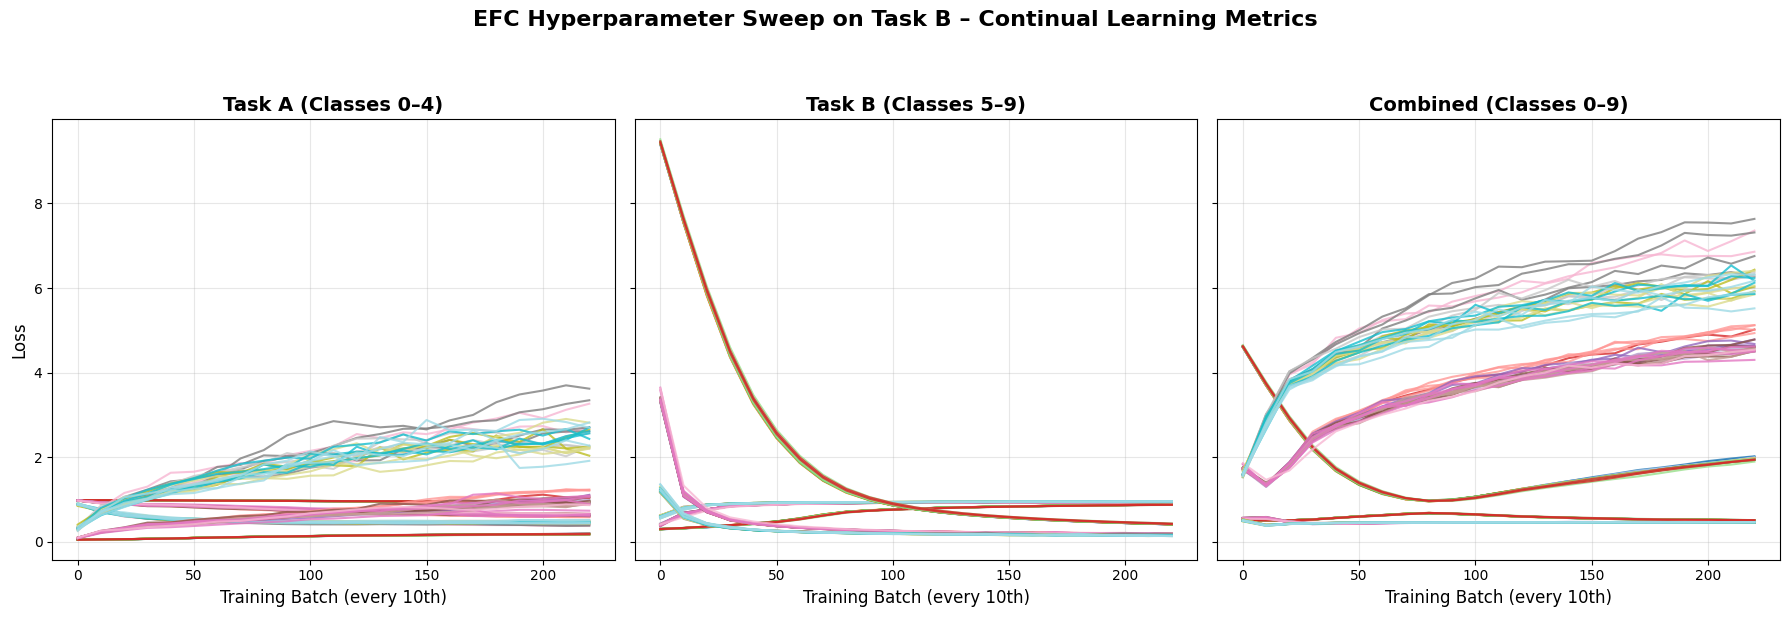

In [99]:
## Plotting: Task A, Task B, Combined – Accuracy & Loss per Hyperparameter

import matplotlib.pyplot as plt
import numpy as np
import pickle
from itertools import product

# --- Load logs if not in memory (uncomment if needed) ---
# with open("efc_hyperopt_logs.pkl", "rb") as f:
#     data = pickle.load(f)
#     acc_logs  = data["acc"]
#     loss_logs = data["loss"]

# --- Ensure logs exist ---
assert 'acc_logs' in globals() and 'loss_logs' in globals(), "Run the hyperparameter sweep cell first!"

# --- Hyperparameter formatting ---
def format_key(key):
    lr, target_lr, beta = key
    return f"lr={lr:.0e}, tgt={target_lr:.0e}, β={beta:.0e}"

# --- Get all hyperparameter keys ---
keys = list(acc_logs.keys())

# --- Determine logging frequency (number of steps) ---
n_steps = len(acc_logs[keys[0]]['A'])
step_indices = np.arange(0, n_steps * 10, 10)  # every 10 batches

# --- Create figure: 1 row, 3 columns ---
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey='row')

# Colors: one per hyperparameter combo
colors = plt.cm.tab20(np.linspace(0, 1, len(keys)))

# --- Plotting function ---
def plot_metric(ax, logs_dict, metric_key, title, ylabel=None, legend=True):
    for key, color in zip(keys, colors):
        values = logs_dict[key][metric_key]
        label = format_key(key)
        ax.plot(step_indices, values, label=label, color=color, linewidth=1.5, alpha=0.8)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel("Training Batch (every 10th)", fontsize=12)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.3)
    if legend:
        ax.legend(fontsize=9, ncol=2, framealpha=0.95, fancybox=True, shadow=True)

# --- Plot 1: Task A ---
plot_metric(axs[0], acc_logs,  'A', "Task A (Classes 0–4)", "Accuracy", legend=False)
plot_metric(axs[0], loss_logs, 'A', "Task A (Classes 0–4)", "Loss", legend=False)
# axs[0].legend([f"{format_key(k)} (acc)" for k in keys] + [f"{format_key(k)} (loss)" for k in keys],
#               fontsize=8, ncol=2, loc='upper left', bbox_to_anchor=(0, 1))

# --- Plot 2: Task B ---
plot_metric(axs[1], acc_logs,  'B', "Task B (Classes 5–9)", legend=False)
plot_metric(axs[1], loss_logs, 'B', "Task B (Classes 5–9)", legend=False)

# --- Plot 3: Combined ---
plot_metric(axs[2], acc_logs,  'combined', "Combined (Classes 0–9)", legend=False)
plot_metric(axs[2], loss_logs, 'combined', "Combined (Classes 0–9)", legend=False)

# --- Final layout ---
plt.suptitle("EFC Hyperparameter Sweep on Task B – Continual Learning Metrics", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# --- Optional: Save figure ---
# plt.savefig("efc_hyperopt_curves.pdf", dpi=300, bbox_inches='tight')
# plt.savefig("efc_hyperopt_curves.png", dpi=300, bbox_inches='tight')

In [100]:
## Print First & Last Loss Values for All Hyperparameter Combinations

from itertools import product
import numpy as np

# --- Ensure logs are loaded ---
assert 'loss_logs' in globals(), "Run the hyperparameter sweep cell first!"

# --- Helper to safely get first/last ---
def safe_first_last(arr):
    if len(arr) == 0:
        return "N/A", "N/A"
    return arr[0], arr[-1]

# --- All hyperparameter combinations (sorted for consistency) ---
keys = sorted(loss_logs.keys(), key=lambda k: (k[0], k[1], k[2]))

print("="*120)
print(f"{'Hyperparameters':<50} {'Task A':<30} {'Task B':<30} {'Combined':<30}")
print(f"{'(lr, target_lr, beta_efc)':<50} "
      f"{'First → Last':<30} {'First → Last':<30} {'First → Last':<30}")
print("-"*120)

for key in keys:
    lr, target_lr, beta = key
    name = f"lr={lr:.0e}, tgt={target_lr:.0e}, β={beta:.0e}"
    
    loss_A = loss_logs[key]['A']
    loss_B = loss_logs[key]['B']
    loss_comb = loss_logs[key]['combined']
    
    first_A, last_A = safe_first_last(loss_A)
    first_B, last_B = safe_first_last(loss_B)
    first_C, last_C = safe_first_last(loss_comb)
    
    def fmt(v): 
        return f"{v:.4f}" if isinstance(v, float) else v
    
    print(f"{name:<50} "
          f"{fmt(first_A)} → {fmt(last_A):<15} "
          f"{fmt(first_B)} → {fmt(last_B):<15} "
          f"{fmt(first_C)} → {fmt(last_C):<15}")

print("="*120)

Hyperparameters                                    Task A                         Task B                         Combined                      
(lr, target_lr, beta_efc)                          First → Last                   First → Last                   First → Last                  
------------------------------------------------------------------------------------------------------------------------
lr=1e-04, tgt=1e-02, β=0e+00                       0.0496 → 0.1842          9.4605 → 0.4159          4.6244 → 1.9699         
lr=1e-04, tgt=1e-02, β=1e-03                       0.0487 → 0.1759          9.5148 → 0.4339          4.6503 → 1.8958         
lr=1e-04, tgt=1e-02, β=5e-03                       0.0490 → 0.1833          9.4468 → 0.4167          4.6174 → 1.9338         
lr=1e-04, tgt=1e-02, β=1e-02                       0.0488 → 0.1911          9.4663 → 0.4283          4.6269 → 1.9469         
lr=1e-04, tgt=1e-02, β=5e-02                       0.0493 → 0.1767          9.4370 → 0.

## Save & Load

In [34]:
out_dir = config.output_dir if hasattr(config, "output_dir") else "./outputs"
os.makedirs(out_dir, exist_ok=True)

theta_0_flat = flatten_params(bp_net_A)

with open(os.path.join(out_dir, "theta_0_flat.pkl"), "wb") as f:
    # detach and move to cpu to ensure picklable tensors
    pickle.dump(theta_0_flat.detach().cpu(), f)

with open(os.path.join(out_dir, "weight_deltas.pkl"), "wb") as f:
    pickle.dump(weight_deltas, f)

with open(os.path.join(out_dir, "acc_logs.pkl"), "wb") as f:
    pickle.dump(acc_logs, f)

with open(os.path.join(out_dir, "loss_logs.pkl"), "wb") as f:
    pickle.dump(loss_logs, f)

print("Saved: bp_net_A_starting_state.pkl, theta_0_flat.pkl, weight_deltas.pkl, acc_logs.pkl, loss_logs.pkl")

Saved: bp_net_A_starting_state.pkl, theta_0_flat.pkl, weight_deltas.pkl, acc_logs.pkl, loss_logs.pkl


In [8]:
# Load previously saved artifacts (theta_0_flat.pkl, weight_deltas.pkl, acc_logs.pkl, loss_logs.pkl)
out_dir = config.output_dir if hasattr(config, "output_dir") else "./outputs"

def _safe_load(fname):
    path = os.path.join(out_dir, fname)
    if not os.path.exists(path):
        print(f"[load] missing: {path}")
        return None
    with open(path, "rb") as f:
        obj = pickle.load(f)
    print(f"[load] loaded: {path} (type={type(obj)})")
    return obj

# Load files
_loaded_theta = _safe_load("theta_0_flat.pkl")
_loaded_weight_deltas = _safe_load("weight_deltas.pkl")
_loaded_acc_logs = _safe_load("acc_logs.pkl")
_loaded_loss_logs = _safe_load("loss_logs.pkl")

# Assign into notebook variables (override only if loaded successfully)
if _loaded_weight_deltas is not None:
    weight_deltas = _loaded_weight_deltas

if _loaded_acc_logs is not None:
    acc_logs = _loaded_acc_logs

if _loaded_loss_logs is not None:
    loss_logs = _loaded_loss_logs

if _loaded_theta is not None:
    # ensure tensor on correct device
    if isinstance(_loaded_theta, torch.Tensor):
        theta_0_flat = _loaded_theta.to(config.device)
    else:
        theta_0_flat = torch.as_tensor(_loaded_theta, device=config.device, dtype=torch.float32)

# Print short summaries
print("\nSummary:")
if isinstance(weight_deltas, dict):
    for m, lst in weight_deltas.items():
        print(f" - weight_deltas[{m}]: {len(lst)} steps")
else:
    print(f" - weight_deltas: {type(weight_deltas)}")

print(f" - acc_logs keys: {list(acc_logs.keys()) if isinstance(acc_logs, dict) else type(acc_logs)}")
print(f" - loss_logs keys: {list(loss_logs.keys()) if isinstance(loss_logs, dict) else type(loss_logs)}")
print(f" - theta_0_flat: {theta_0_flat.shape if isinstance(theta_0_flat, torch.Tensor) else type(theta_0_flat)}")

[load] loaded: ./outputs/theta_0_flat.pkl (type=<class 'torch.Tensor'>)
[load] loaded: ./outputs/weight_deltas.pkl (type=<class 'dict'>)
[load] loaded: ./outputs/acc_logs.pkl (type=<class 'dict'>)
[load] loaded: ./outputs/loss_logs.pkl (type=<class 'dict'>)

Summary:
 - weight_deltas[bp]: 20 steps
 - weight_deltas[ewc]: 20 steps
 - weight_deltas[efc]: 20 steps
 - weight_deltas[ehc]: 20 steps
 - acc_logs keys: ['bp', 'ewc', 'efc', 'ehc']
 - loss_logs keys: ['bp', 'ewc', 'efc', 'ehc']
 - theta_0_flat: torch.Size([55050])


## (0) Performance metrics

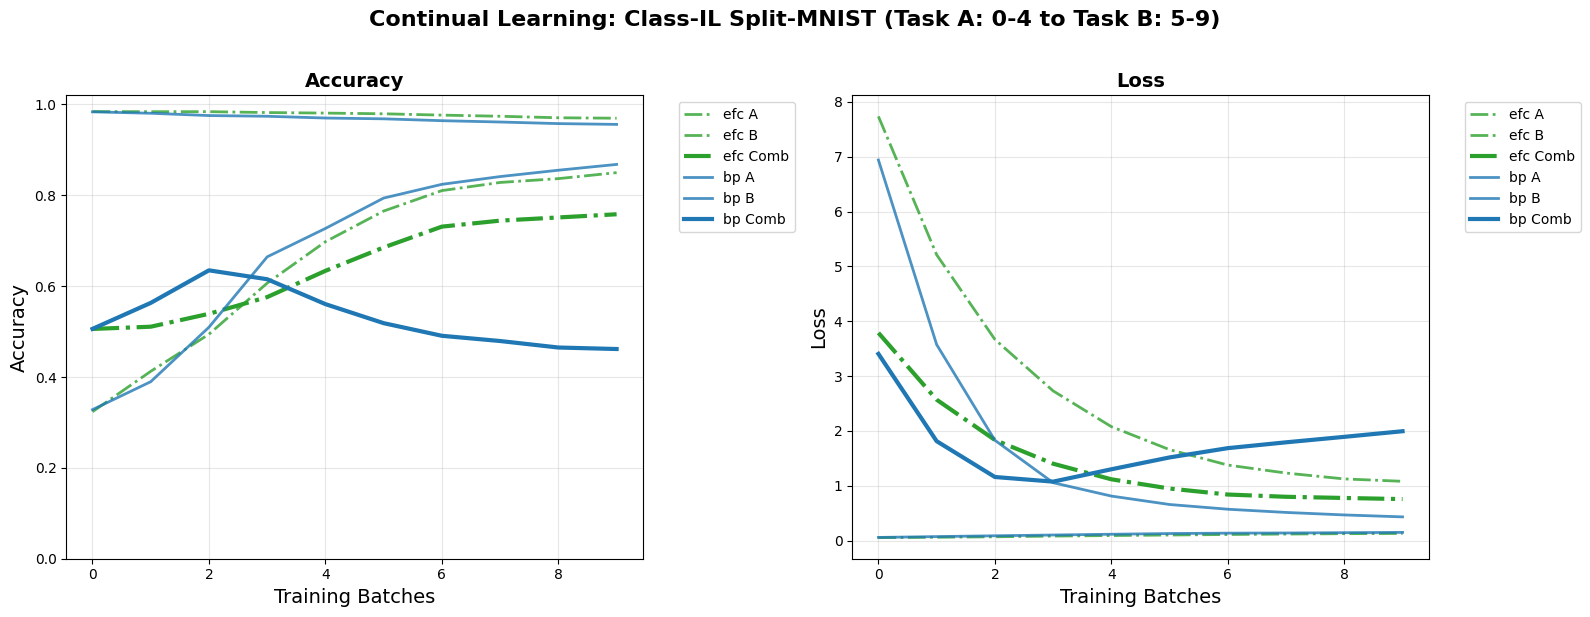


FINAL RESULTS (after Task B)
bp       | A: 0.816 (L: 0.572) | B: 0.976 (L: 0.075) | Comb: 0.474 (L: 5.178)
ewc      | A: 0.900 (L: 0.290) | B: 0.974 (L: 0.082) | Comb: 0.474 (L: 3.819)
efc      | A: 0.968 (L: 0.168) | B: 0.937 (L: 0.437) | Comb: 0.702 (L: 0.829)


In [175]:
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

colors = {'bp': 'tab:blue', 'ewc': 'tab:orange', 'efc': 'tab:green', 'ehc': 'tab:red'}
linestyles = {'bp': '-', 'ewc': '--', 'efc': '-.', 'ehc': ':'}

for name in ['efc','bp']:
    x = np.arange(len(acc_logs[name]['acc_A']))

    # --- Accuracy subplot ---
    ax_acc.plot(x[:10], acc_logs[name]['acc_A'][:10], label=f'{name} A', color=colors[name], linestyle=linestyles[name], lw=2, alpha=0.8)
    ax_acc.plot(x[:10], acc_logs[name]['acc_B'][:10], label=f'{name} B', color=colors[name], linestyle=linestyles[name], lw=2, alpha=0.8)
    ax_acc.plot(x[:10], acc_logs[name]['combined'][:10], label=f'{name} Comb', color=colors[name], linestyle=linestyles[name], lw=3)

    # --- Loss subplot ---
    ax_loss.plot(x[:10], loss_logs[name]['loss_A'][:10], label=f'{name} A', color=colors[name], linestyle=linestyles[name], lw=2, alpha=0.8)
    ax_loss.plot(x[:10], loss_logs[name]['loss_B'][:10], label=f'{name} B', color=colors[name], linestyle=linestyles[name], lw=2, alpha=0.8)
    ax_loss.plot(x[:10], loss_logs[name]['combined'][:10], label=f'{name} Comb', color=colors[name], linestyle=linestyles[name], lw=3)

# --- Formatting ---
ax_acc.set_xlabel('Training Batches', fontsize=14)
ax_acc.set_ylabel('Accuracy', fontsize=14)
ax_acc.set_title('Accuracy', fontsize=14, fontweight='bold')
ax_acc.set_ylim(0, 1.02)
ax_acc.grid(True, alpha=0.3)
ax_acc.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

ax_loss.set_xlabel('Training Batches', fontsize=14)
ax_loss.set_ylabel('Loss', fontsize=14)
ax_loss.set_title('Loss', fontsize=14, fontweight='bold')
ax_loss.grid(True, alpha=0.3)
ax_loss.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

fig.suptitle('Continual Learning: Class-IL Split-MNIST (Task A: 0-4 to Task B: 5-9)', 
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# --- Final metrics ---
print("\n" + "="*70)
print("FINAL RESULTS (after Task B)")
print("="*70)
for name in nets.keys():
    print(f"{name:8s} | "
          f"A: {acc_logs[name]['acc_A'][-1]:.3f} (L: {loss_logs[name]['loss_A'][-1]:.3f}) | "
          f"B: {acc_logs[name]['acc_B'][-1]:.3f} (L: {loss_logs[name]['loss_B'][-1]:.3f}) | "
          f"Comb: {acc_logs[name]['combined'][-1]:.3f} (L: {loss_logs[name]['combined'][-1]:.3f})")
print("="*70)

## (1) Task A Loss Contour Plot

In [45]:
# Flatten all trainable params
def flatten_params(model):
    return torch.cat([p.flatten() for p in model.parameters() if p.requires_grad])

# Unflatten vector back to model
def unflatten_params(flat_vec, model):
    offset = 0
    for p in model.parameters():
        if p.requires_grad:
            numel = p.numel()
            p.data.copy_(flat_vec[offset:offset + numel].view(p.shape))
            offset += numel

# Evaluate Task A loss on full test set
def loss_A_at_params(model, params_flat, test_loader_A):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    model.eval()
    model.task_id = 0
    total_loss = 0.0
    total_samples = 0
    with torch.no_grad():
        for x, y in test_loader_A:
            x, y = x.to(model.device), y.to(model.device)
            out = model(x)
            loss = model.loss_fn(out, y.argmax(dim=1))
            total_loss += loss.item() * x.size(0)
            total_samples += x.size(0)
    unflatten_params(orig_flat, model)  # restore
    return total_loss / total_samples if total_samples > 0 else 0.0

In [46]:
num_steps = 20
theta_0_flat = flatten_params(bp_net_A)  # center (0,0)

# EHC end point (y-axis: optimal second-order)
ehc_end_flat = theta_0_flat.clone()
for step in range(num_steps):
    delta_dict = weight_deltas['efc'][step]
    delta_flat = torch.cat([d.flatten() for d in delta_dict.values()])
    ehc_end_flat += delta_flat

# BP_B end point (x-axis: worst first-order)
bp_end_flat = theta_0_flat.clone()
for step in range(num_steps):
    delta_dict = weight_deltas['bp'][step]
    delta_flat = torch.cat([d.flatten() for d in delta_dict.values()])
    bp_end_flat += delta_flat

# Directions (normalized)
d1 = ehc_end_flat - theta_0_flat
d2 = bp_end_flat - theta_0_flat

len_d1 = d1.norm()
len_d2 = d2.norm()

d1_norm = d1 / len_d1
d2_norm = d2 / len_d2

# proj = (d2_norm @ d1_norm).item()
# d2_orth = d2_norm - proj * d1_norm
# len_d2_orth = d2_orth.norm()
# d2_orth_norm = d2_orth / len_d2_orth

In [47]:
grid_size = 40
grid_range = 1.2  # [0, 1.2] in scaled units

# Create meshgrid
alpha, beta = np.meshgrid(
    np.linspace(-grid_range, grid_range, grid_size),
    np.linspace(-grid_range, grid_range, grid_size)
)

losses_A = np.zeros((grid_size, grid_size))

print("Evaluating Task A loss on [-1.2,1.2]x[-1.2,1.2] parameter grid...")
pbar = tqdm(total=grid_size**2, desc="Grid Eval", unit="point")

for i in range(grid_size):
    for j in range(grid_size):
        delta = alpha[i,j] * len_d2 * d2_norm + beta[i,j] * len_d1 * d1_norm
        interp_params = theta_0_flat + delta
        losses_A[i, j] = loss_A_at_params(bp_net_A, interp_params, test_loader_A)
        pbar.update(1)

pbar.close()
print("Grid evaluation complete.")

Evaluating Task A loss on [-1.2,1.2]x[-1.2,1.2] parameter grid...


Grid Eval: 100%|██████████| 1600/1600 [00:31<00:00, 51.19point/s]

Grid evaluation complete.


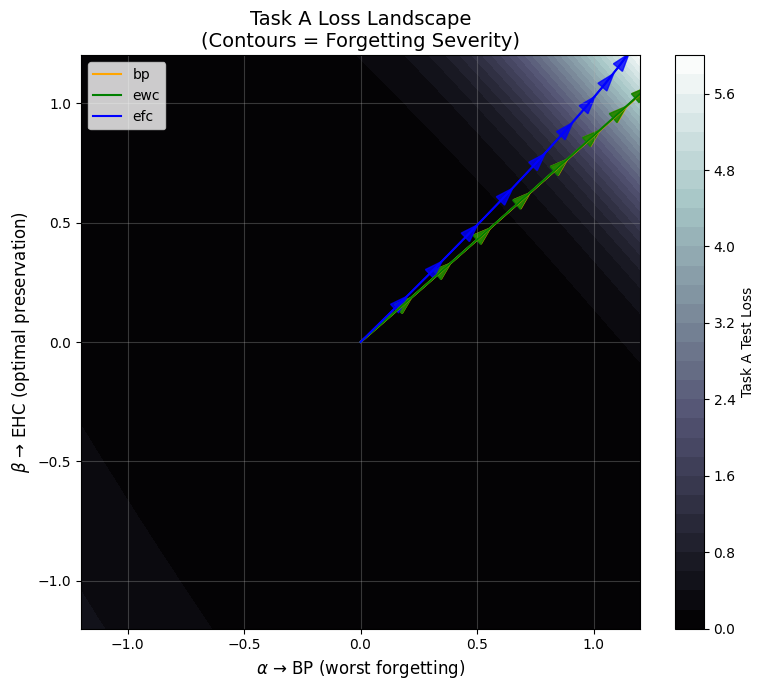

In [49]:
plt.figure(figsize=(8, 7))
plt.contourf(alpha, beta, losses_A, levels=30, cmap='bone')
plt.colorbar(label='Task A Test Loss')

# Method colors
colors = {'bp': 'orange', 'ewc': 'green', 'efc': 'blue', 'ehc': 'red'}
methods = ['bp', 'ewc', 'efc']#, 'ehc']

# Plot each method's trajectory (cumulative over 5 steps)
for method in methods:
    cum_flat = theta_0_flat.clone()
    traj_x, traj_y = [0.0], [0.0]
    for step in range(20):
        delta_flat = torch.cat([d.flatten() for d in weight_deltas[method][step].values()])
        cum_flat += delta_flat

        proj_x = float(((cum_flat - theta_0_flat) @ d2_norm).item())
        proj_y = float(((cum_flat - theta_0_flat) @ d1_norm).item())

        traj_x.append(proj_x)
        traj_y.append(proj_y)

    traj_x = np.array(traj_x, dtype=np.float64)
    traj_y = np.array(traj_y, dtype=np.float64)

    plt.plot(traj_x, traj_y, '-', color=colors[method], label=method)
    for k in range(1, len(traj_x)):
        plt.arrow(traj_x[k-1], traj_y[k-1],
                  traj_x[k] - traj_x[k-1], traj_y[k] - traj_y[k-1],
                  color=colors[method], head_width=0.05, alpha=0.8)

plt.xlim(-grid_range, grid_range)
plt.ylim(-grid_range, grid_range)
plt.xlabel(r'$\alpha$ → BP (worst forgetting)', fontsize=12)
plt.ylabel(r'$\beta$ → EHC (optimal preservation)', fontsize=12)
plt.title('Task A Loss Landscape\n(Contours = Forgetting Severity)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## (1a) PCA Contour plot

In [155]:
# Flatten all trainable params
def flatten_params(model):
    return torch.cat([p.flatten() for p in model.parameters() if p.requires_grad])

# Unflatten vector back to model
def unflatten_params(flat_vec, model):
    offset = 0
    for p in model.parameters():
        if p.requires_grad:
            numel = p.numel()
            p.data.copy_(flat_vec[offset:offset + numel].view(p.shape))
            offset += numel

def evaluate(net, loader, task_id, task_classes):
    net.eval()
    correct = total = 0.0
    total_loss = 0.0
    task_set = set(range(task_classes[0], task_classes[1] + 1))
    criterion = net.loss_fn  # CE or MSE

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(config.device), y.to(config.device)
            net.task_id = task_id
            out = net(x)
            true_labels = y.argmax(1)

            mask = torch.isin(true_labels, torch.tensor(list(task_set), device=config.device))
            if not mask.any():
                continue

            out = out[mask]
            y = y[mask]
            true_labels = true_labels[mask]

            start_idx = task_classes[0]
            pred_rel = out[:, start_idx:task_classes[1]+1].argmax(1)
            pred_abs = pred_rel + start_idx

            correct += (pred_abs == true_labels).sum().item()
            total += true_labels.size(0)
            total_loss += criterion(out[:, :task_classes[1]+1], y.argmax(1)).item() * true_labels.size(0)

    acc = correct / total if total else 0.0
    loss = total_loss / total if total else 0.0
    return acc, loss

# Evaluate losses using evaluate()
def loss_A_at_params(model, params_flat, test_loader_A):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    _, loss = evaluate(model, test_loader_A, task_id=0, task_classes=[0, 4])
    unflatten_params(orig_flat, model)
    return loss

def loss_B_at_params(model, params_flat, test_loader_B):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    _, loss = evaluate(model, test_loader_B, task_id=1, task_classes=[5, 9])
    unflatten_params(orig_flat, model)
    return loss

def loss_combined_at_params(model, params_flat, test_loader_B):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    _, loss = evaluate(model, test_loader_B, task_id=1, task_classes=[0, 9])
    unflatten_params(orig_flat, model)
    return loss

def acc_loss_A_at_params(model, params_flat, test_loader_A):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    acc, loss = evaluate(model, test_loader_A, task_id=0, task_classes=[0, 4])
    unflatten_params(orig_flat, model)
    return acc, loss

def acc_loss_B_at_params(model, params_flat, test_loader_B):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    acc, loss = evaluate(model, test_loader_B, task_id=1, task_classes=[5, 9])
    unflatten_params(orig_flat, model)
    return acc, loss

def acc_loss_combined_at_params(model, params_flat, test_loader_B):
    orig_flat = flatten_params(model)
    unflatten_params(params_flat, model)
    acc, loss = evaluate(model, test_loader_B, task_id=1, task_classes=[0, 9])
    unflatten_params(orig_flat, model)
    return acc, loss

In [151]:
num_steps = 20

# Collect all deltas into a matrix for PCA
methods = ['bp', 'ewc', 'efc']#, 'ehc']
delta_matrix = []
for method in methods:
    for step in range(num_steps):
        delta_dict = weight_deltas[method][step]
        delta_flat = torch.cat([d.flatten() for d in delta_dict.values()])
        delta_matrix.append(delta_flat.cpu().detach().numpy())

delta_matrix = np.array(delta_matrix).T  # Shape: (p, M * S)

theta_0_flat = flatten_params(bp_net_A)

# Perform PCA
pca = PCA(n_components=2)
pca.fit(delta_matrix.T)  # Fit on (M*S, p)
pc1 = torch.from_numpy(pca.components_[0]).to(theta_0_flat.device).float()
pc2 = torch.from_numpy(pca.components_[1]).to(theta_0_flat.device).float()

len_pc1 = pc1.norm()
len_pc2 = pc2.norm()
pc1_norm = pc1 / len_pc1
pc2_norm = pc2 / len_pc2

In [56]:
grid_size = 20
grid_range = 10

alpha, beta = np.meshgrid(
    np.linspace(-0.75, 0.1, grid_size),
    np.linspace(0, 1.3, grid_size)
)

losses_A = np.zeros((grid_size, grid_size))
losses_B = np.zeros((grid_size, grid_size))
losses_combined = np.zeros((grid_size, grid_size))

print("Evaluating losses on PCA-projected grid")
pbar = tqdm(total=grid_size**2, desc="Grid Eval", unit="point")

for i in range(grid_size):
    for j in range(grid_size):
        delta = alpha[i,j] * len_pc2 * pc2_norm + beta[i,j] * len_pc1 * pc1_norm
        interp_params = theta_0_flat + delta

        losses_A[i, j] = loss_A_at_params(bp_net_A, interp_params, test_loader_A)
        losses_B[i, j] = loss_B_at_params(bp_net_A, interp_params, test_loader_B)
        losses_combined[i, j] = loss_combined_at_params(bp_net_A, interp_params, test_loader_B)
        pbar.update(1)

pbar.close()
print(f"Grid evaluation complete. Variance explained: {pca.explained_variance_ratio_}")

Evaluating losses on PCA-projected grid


Grid Eval: 100%|██████████| 400/400 [00:39<00:00, 10.20point/s]

Grid evaluation complete. Variance explained: [0.67829096 0.14481284]


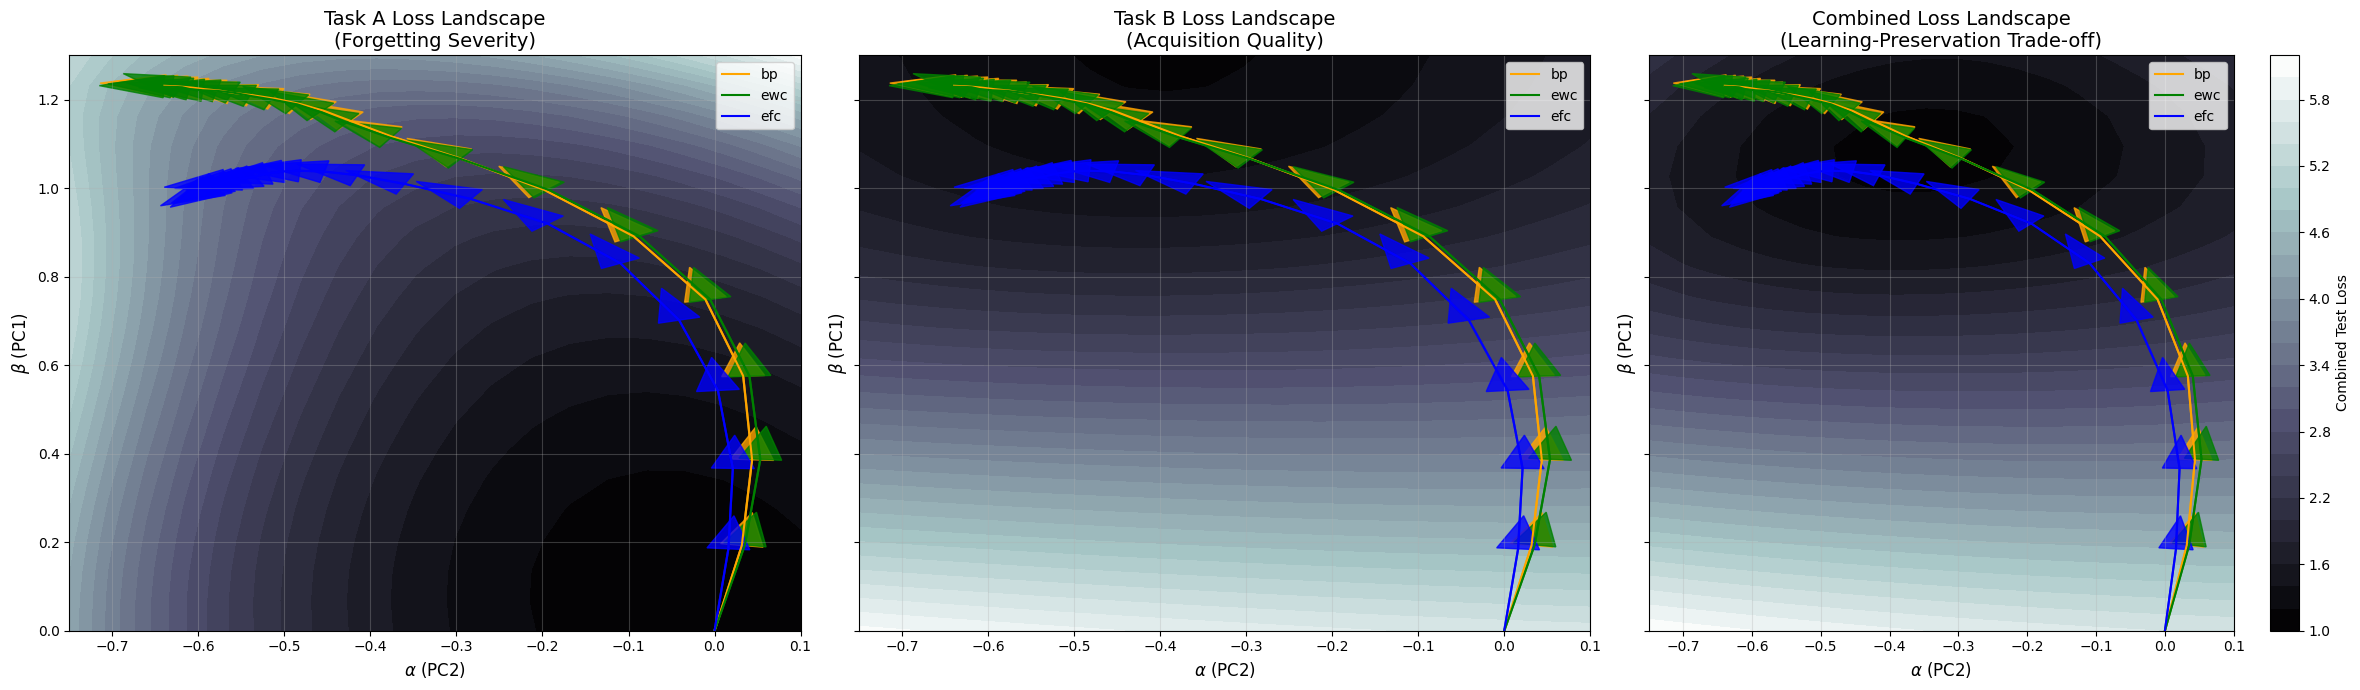

In [58]:
# Plotting
fig, axs = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# Method colors
colors = {'bp': 'orange', 'ewc': 'green', 'efc': 'blue', 'ehc': 'red'}

# Function to plot trajectories on a given ax
def plot_trajectories(ax):
    for method in methods:
        cum_flat = theta_0_flat.clone()
        traj_x, traj_y = [0.0], [0.0]
        for step in range(num_steps):
            delta_flat = torch.cat([d.flatten() for d in weight_deltas[method][step].values()])
            cum_flat += delta_flat

            proj_x = float(((cum_flat - theta_0_flat) @ pc2_norm).item())
            proj_y = float(((cum_flat - theta_0_flat) @ pc1_norm).item())

            traj_x.append(proj_x)
            traj_y.append(proj_y)

        traj_x = np.array(traj_x, dtype=np.float64)
        traj_y = np.array(traj_y, dtype=np.float64)

        ax.plot(traj_x, traj_y, '-', color=colors[method], label=method)
        for k in range(1, len(traj_x)):
            ax.arrow(traj_x[k-1], traj_y[k-1],
                     traj_x[k] - traj_x[k-1], traj_y[k] - traj_y[k-1],
                     color=colors[method], head_width=0.05, alpha=0.8)

# Plot 1: Task A
axs[0].contourf(alpha, beta, losses_A, levels=30, cmap='bone')
axs[0].set_title('Task A Loss Landscape\n(Forgetting Severity)', fontsize=14)
plot_trajectories(axs[0])

# Plot 2: Task B
axs[1].contourf(alpha, beta, losses_B, levels=30, cmap='bone')
axs[1].set_title('Task B Loss Landscape\n(Acquisition Quality)', fontsize=14)
plot_trajectories(axs[1])

# Plot 3: Combined
c = axs[2].contourf(alpha, beta, losses_combined, levels=30, cmap='bone')
axs[2].set_title('Combined Loss Landscape\n(Learning-Preservation Trade-off)', fontsize=14)
plot_trajectories(axs[2])
fig.colorbar(c, ax=axs[2], label='Combined Test Loss')

for ax in axs:
    ax.set_xlim(-0.75, 0.1)
    ax.set_ylim(0, 1.3)
    ax.set_xlabel(r'$\alpha$ (PC2)', fontsize=12)
    ax.set_ylabel(r'$\beta$ (PC1)', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [165]:
## 1. Recompute PCA using first 2 epochs (12 steps/epoch → first 24 steps)
num_steps_per_epoch = 12
num_epochs_to_use   = 1
total_steps         = num_steps_per_epoch * num_epochs_to_use  # 24

methods = ['bp', 'ewc', 'efc']

# Collect weight deltas from first 24 steps
delta_matrix = []
for method in methods:
    for step in range(total_steps):
        if step >= len(weight_deltas[method]):
            print(f"Warning: {method} only has {len(weight_deltas[method])} steps. Stopping.")
            break
        delta_dict = weight_deltas[method][step]
        delta_flat = torch.cat([d.flatten() for d in delta_dict.values()])
        delta_matrix.append(delta_flat.cpu().detach().numpy())

delta_matrix = np.array(delta_matrix).T  # Shape: (p, M * S)

theta_0_flat = flatten_params(bp_net_A)

# Perform PCA on first 5 epochs
pca = PCA(n_components=2)
pca.fit(delta_matrix.T)
pc1 = torch.from_numpy(pca.components_[0]).to(theta_0_flat.device).float()
pc2 = torch.from_numpy(pca.components_[1]).to(theta_0_flat.device).float()

len_pc1 = pc1.norm()
len_pc2 = pc2.norm()
pc1_norm = pc1 / len_pc1
pc2_norm = pc2 / len_pc2

print(f"PCA recomputed on first {num_epochs_to_use} epochs ({total_steps} steps).")
print(f"Variance explained: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")

PCA recomputed on first 1 epochs (12 steps).
Variance explained: PC1=0.647, PC2=0.120


In [166]:
## 2. Project trajectories AND store full parameters

traj_projections = {m: {'alpha': [], 'beta': [], 'params': []} for m in methods}

for method in methods:
    cum_flat = theta_0_flat.clone()
    max_steps = min(total_steps, len(weight_deltas[method]))

    # Start at origin
    proj_alpha = float(((cum_flat - theta_0_flat) @ pc2_norm).item())
    proj_beta  = float(((cum_flat - theta_0_flat) @ pc1_norm).item())
    traj_projections[method]['alpha'].append(proj_alpha)
    traj_projections[method]['beta'].append(proj_beta)
    traj_projections[method]['params'].append(cum_flat.clone())  # STORE FULL PARAMS

    for step in range(max_steps):
        delta_dict = weight_deltas[method][step]
        delta_flat = torch.cat([d.flatten() for d in delta_dict.values()])
        cum_flat += delta_flat

        proj_alpha = float(((cum_flat - theta_0_flat) @ pc2_norm).item())
        proj_beta  = float(((cum_flat - theta_0_flat) @ pc1_norm).item())
        traj_projections[method]['alpha'].append(proj_alpha)
        traj_projections[method]['beta'].append(proj_beta)
        traj_projections[method]['params'].append(cum_flat.clone())  # STORE FULL PARAMS

    print(f"{method.upper()}: {len(traj_projections[method]['alpha'])} points (incl. start)")

BP: 13 points (incl. start)
EWC: 13 points (incl. start)
EFC: 13 points (incl. start)


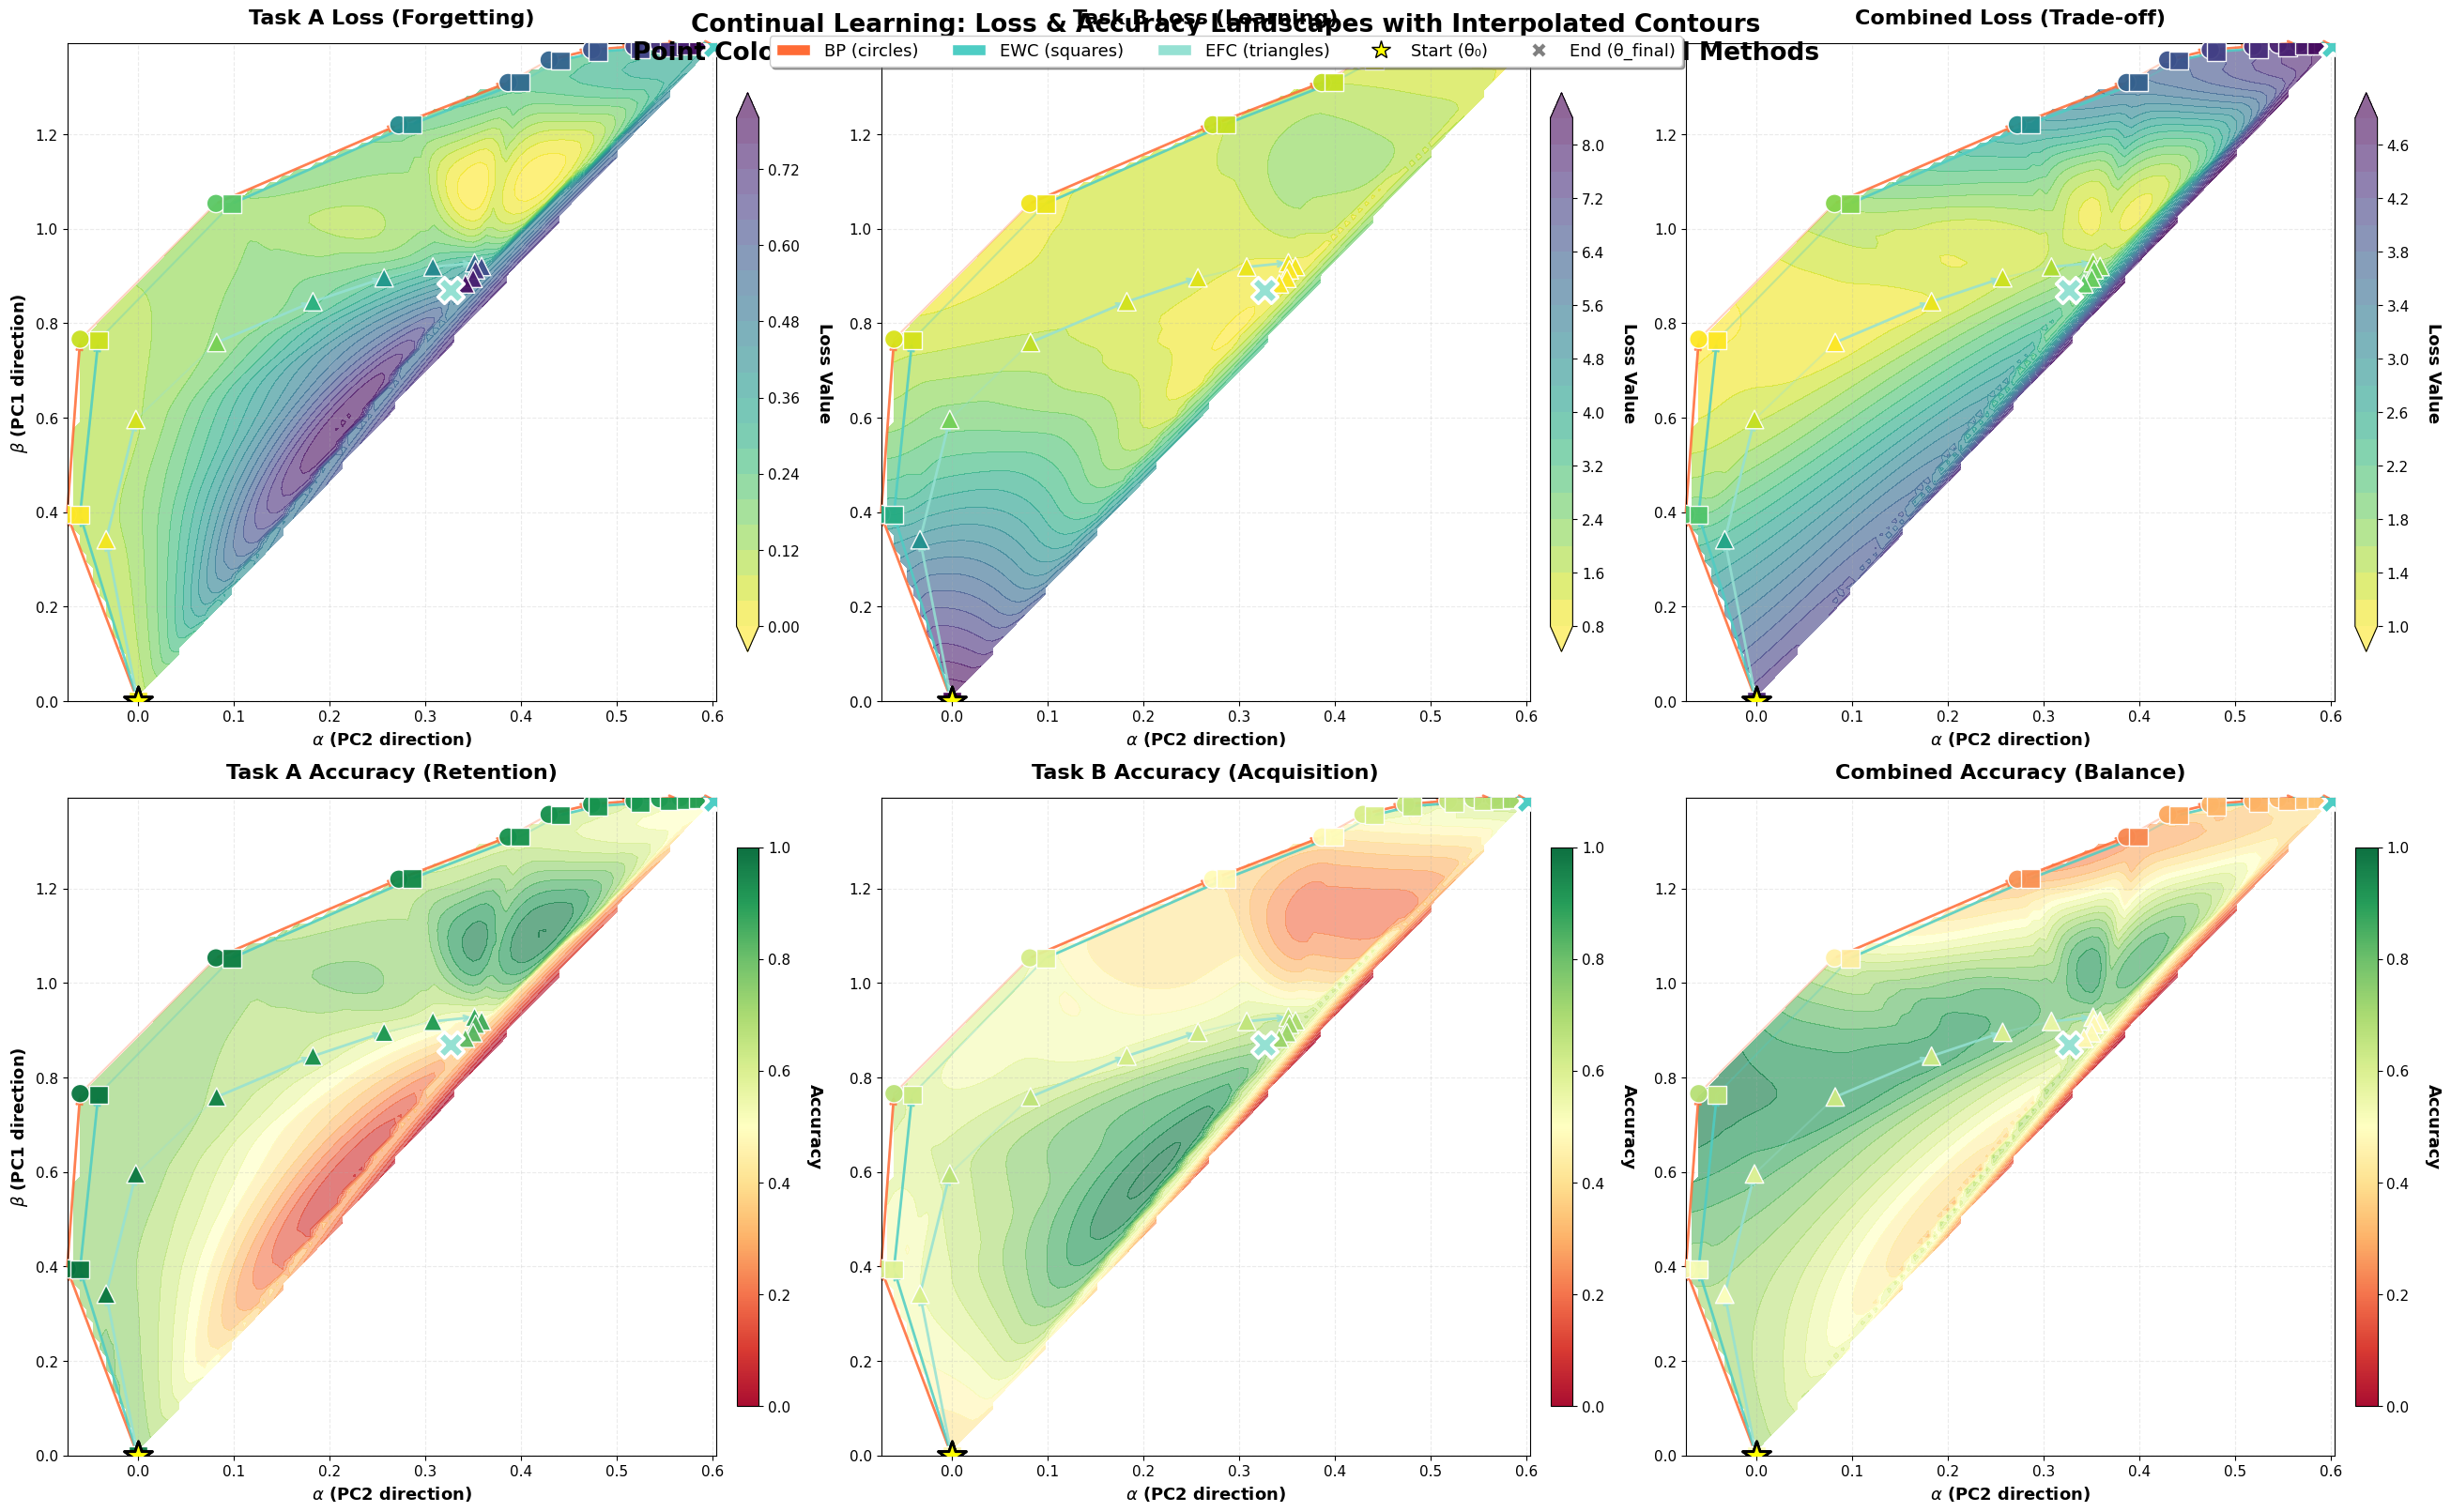

In [168]:
from scipy.interpolate import griddata
import matplotlib.patches as mpatches

# Create figure with better layout: 2 rows (loss/acc) × 3 cols (Task A/B/Combined)
fig, axs = plt.subplots(2, 3, figsize=(26, 16), constrained_layout=True)

# Colors and markers for methods
colors = {'bp': '#FF6B35', 'ewc': '#4ECDC4', 'efc': '#95E1D3'}
marker_styles = {'bp': 'o', 'ewc': 's', 'efc': '^'}

# Metrics to plot
loss_keys = ['loss_A', 'loss_B', 'loss_C']
acc_keys = ['acc_A', 'acc_B', 'acc_C']
loss_titles = ['Task A Loss (Forgetting)', 'Task B Loss (Learning)', 'Combined Loss (Trade-off)']
acc_titles = ['Task A Accuracy (Retention)', 'Task B Accuracy (Acquisition)', 'Combined Accuracy (Balance)']

# Helper function to create interpolated contours from scattered points
def create_contour_from_points(ax, all_alphas, all_betas, all_values, cmap, label):
    """Interpolate scattered points to create smooth contour background"""
    # Create dense grid for interpolation
    grid_alpha = np.linspace(min(all_alphas), max(all_alphas), 100)
    grid_beta = np.linspace(min(all_betas), max(all_betas), 100)
    grid_alpha_mesh, grid_beta_mesh = np.meshgrid(grid_alpha, grid_beta)
    
    # Interpolate using cubic method (smoother) or linear
    try:
        grid_values = griddata(
            (all_alphas, all_betas), 
            all_values,
            (grid_alpha_mesh, grid_beta_mesh),
            method='cubic',  # Smooth interpolation
            fill_value=np.nan
        )
    except:
        # Fallback to linear if cubic fails
        grid_values = griddata(
            (all_alphas, all_betas), 
            all_values,
            (grid_alpha_mesh, grid_beta_mesh),
            method='linear',
            fill_value=np.nan
        )
    
    # Plot contours
    contour = ax.contourf(grid_alpha_mesh, grid_beta_mesh, grid_values, 
                          levels=20, cmap=cmap, alpha=0.6, extend='both')
    
    return contour

# Plot loss landscapes (top row)
for col, (loss_key, title) in enumerate(zip(loss_keys, loss_titles)):
    ax = axs[0, col]
    
    # Collect all points for contour interpolation
    all_alphas = np.concatenate([trajectory_data[m]['alpha'] for m in methods])
    all_betas = np.concatenate([trajectory_data[m]['beta'] for m in methods])
    all_losses = np.concatenate([trajectory_data[m][loss_key] for m in methods])
    
    # Create interpolated contour background
    contour = create_contour_from_points(ax, all_alphas, all_betas, all_losses, 
                                         'viridis_r', 'Loss')
    
    # Plot trajectories on top
    for method in methods:
        alphas = trajectory_data[method]['alpha']
        betas = trajectory_data[method]['beta']
        losses = trajectory_data[method][loss_key]
        
        # Trajectory line (thin, subtle)
        ax.plot(alphas, betas, '-', color=colors[method], linewidth=1.5, 
                alpha=0.3, zorder=2)
        
        # Large scatter points colored by loss
        scatter = ax.scatter(alphas, betas, 
                           c=losses, 
                           cmap='viridis_r',
                           s=200,  # MUCH LARGER
                           marker=marker_styles[method],
                           edgecolor='white',  # White edge for visibility
                           linewidth=1,
                           alpha=0.95,
                           zorder=3)
        
        # Direction arrows (fewer, more visible)
        arrow_indices = np.linspace(0, len(alphas)-2, 8, dtype=int)
        for i in arrow_indices:
            ax.annotate('', xy=(alphas[i+1], betas[i+1]), xytext=(alphas[i], betas[i]),
                       arrowprops=dict(arrowstyle='->', color=colors[method], 
                                     lw=2, alpha=0.8), zorder=2)
        
        # Start point (large star)
        ax.scatter(alphas[0], betas[0], s=500, marker='*', 
                  color='yellow', edgecolor='black', linewidth=2, 
                  zorder=4)
        
        # End point (large X with method color)
        ax.scatter(alphas[-1], betas[-1], s=400, marker='X', 
                  color=colors[method], edgecolor='white', linewidth=2.5, 
                  zorder=4)
    
    # Colorbar
    cbar = plt.colorbar(contour, ax=ax, shrink=0.85, aspect=25, pad=0.02)
    cbar.set_label('Loss Value', rotation=270, labelpad=25, fontsize=13, fontweight='bold')
    cbar.ax.tick_params(labelsize=11)
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(r'$\alpha$ (PC2 direction)', fontsize=13, fontweight='bold')
    if col == 0:
        ax.set_ylabel(r'$\beta$ (PC1 direction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
    ax.tick_params(labelsize=11)

# Plot accuracy landscapes (bottom row)
for col, (acc_key, title) in enumerate(zip(acc_keys, acc_titles)):
    ax = axs[1, col]
    
    # Collect all points for contour interpolation
    all_alphas = np.concatenate([trajectory_data[m]['alpha'] for m in methods])
    all_betas = np.concatenate([trajectory_data[m]['beta'] for m in methods])
    all_accs = np.concatenate([trajectory_data[m][acc_key] for m in methods])
    
    # Create interpolated contour background
    contour = create_contour_from_points(ax, all_alphas, all_betas, all_accs, 
                                         'RdYlGn', 'Accuracy')
    
    # Plot trajectories on top
    for method in methods:
        alphas = trajectory_data[method]['alpha']
        betas = trajectory_data[method]['beta']
        accs = trajectory_data[method][acc_key]
        
        # Trajectory line
        ax.plot(alphas, betas, '-', color=colors[method], linewidth=1.5, 
                alpha=0.3, zorder=2)
        
        # Large scatter points colored by accuracy
        scatter = ax.scatter(alphas, betas, 
                           c=accs, 
                           cmap='RdYlGn',
                           s=200,  # MUCH LARGER
                           marker=marker_styles[method],
                           edgecolor='white',
                           linewidth=1,
                           alpha=0.95,
                           vmin=0.0,
                           vmax=1.0,
                           zorder=3)
        
        # Direction arrows
        arrow_indices = np.linspace(0, len(alphas)-2, 8, dtype=int)
        for i in arrow_indices:
            ax.annotate('', xy=(alphas[i+1], betas[i+1]), xytext=(alphas[i], betas[i]),
                       arrowprops=dict(arrowstyle='->', color=colors[method], 
                                     lw=2, alpha=0.8), zorder=2)
        
        # Start and end points
        ax.scatter(alphas[0], betas[0], s=500, marker='*', 
                  color='yellow', edgecolor='black', linewidth=2, 
                  zorder=4)
        ax.scatter(alphas[-1], betas[-1], s=400, marker='X', 
                  color=colors[method], edgecolor='white', linewidth=2.5, 
                  zorder=4)
    
    # Colorbar
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.85, aspect=25, pad=0.02)
    cbar.set_label('Accuracy', rotation=270, labelpad=25, fontsize=13, fontweight='bold')
    cbar.ax.tick_params(labelsize=11)
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel(r'$\alpha$ (PC2 direction)', fontsize=13, fontweight='bold')
    if col == 0:
        ax.set_ylabel(r'$\beta$ (PC1 direction)', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
    ax.tick_params(labelsize=11)

# Create custom legend for methods (shared across all subplots)
legend_elements = [
    mpatches.Patch(facecolor=colors['bp'], edgecolor='white', label='BP (circles)'),
    mpatches.Patch(facecolor=colors['ewc'], edgecolor='white', label='EWC (squares)'),
    mpatches.Patch(facecolor=colors['efc'], edgecolor='white', label='EFC (triangles)'),
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='yellow', 
               markeredgecolor='black', markersize=15, label='Start (θ₀)'),
    plt.Line2D([0], [0], marker='X', color='w', markerfacecolor='gray', 
               markeredgecolor='white', markersize=12, label='End (θ_final)'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=5, 
          fontsize=13, frameon=True, fancybox=True, shadow=True,
          bbox_to_anchor=(0.5, 0.985))

plt.suptitle('Continual Learning: Loss & Accuracy Landscapes with Interpolated Contours\n' + 
             'Point Colors = Metric Value  |  Background Contours = Interpolated from All Methods',
             fontsize=19, fontweight='bold', y=0.995)

plt.show()

In [161]:
# === 2. Compute min/max with margin ===
all_alphas = np.concatenate([traj_projections[m]['alpha'] for m in methods])
all_betas  = np.concatenate([traj_projections[m]['beta']  for m in methods])

alpha_min, alpha_max = all_alphas.min(), all_alphas.max()
beta_min,  beta_max  = all_betas.min(),  all_betas.max()

# Add 15% margin
margin_a = 0.15 * (alpha_max - alpha_min)
margin_b = 0.15 * (beta_max - beta_min)

alpha_range = [alpha_min - margin_a, alpha_max + margin_a]
beta_range  = [beta_min  - margin_b, beta_max  + margin_b]

print(f"Auto-computed ranges:")
print(f"  alpha (PC2): [{alpha_range[0]:.3f}, {alpha_range[1]:.3f}]")
print(f"  beta  (PC1): [{beta_range[0]:.3f}, {beta_range[1]:.3f}]")

# === Grid setup (same as before) ===
grid_size = 20
alpha_grid = np.linspace(alpha_range[0], alpha_range[1], grid_size)
beta_grid  = np.linspace(beta_range[0],  beta_range[1],  grid_size)
alpha, beta = np.meshgrid(alpha_grid, beta_grid)

# Storage for both loss and accuracy
losses_A = np.zeros((grid_size, grid_size))
losses_B = np.zeros((grid_size, grid_size))
losses_combined = np.zeros((grid_size, grid_size))

accs_A = np.zeros((grid_size, grid_size))
accs_B = np.zeros((grid_size, grid_size))
accs_combined = np.zeros((grid_size, grid_size))

# === Grid evaluation ===
print("Evaluating loss and accuracy landscapes on auto-ranged grid...")
pbar = tqdm(total=grid_size**2, desc="Grid Eval", unit="point")

for i in range(grid_size):
    for j in range(grid_size):
        delta = alpha[i,j] * len_pc2 * pc2_norm + beta[i,j] * len_pc1 * pc1_norm
        interp_params = theta_0_flat + delta

        accs_A[i, j], losses_A[i, j] = acc_loss_A_at_params(bp_net_A, interp_params, test_loader_A)
        accs_B[i, j], losses_B[i, j] = acc_loss_B_at_params(bp_net_A, interp_params, test_loader_B)
        accs_combined[i, j], losses_combined[i, j] = acc_loss_combined_at_params(bp_net_A, interp_params, test_loader_B)
        pbar.update(1)
pbar.close()

Auto-computed ranges:
  alpha (PC2): [-0.940, 0.252]
  beta  (PC1): [-0.237, 1.816]
Evaluating loss and accuracy landscapes on auto-ranged grid...


Grid Eval: 100%|██████████| 400/400 [00:40<00:00,  9.84point/s]


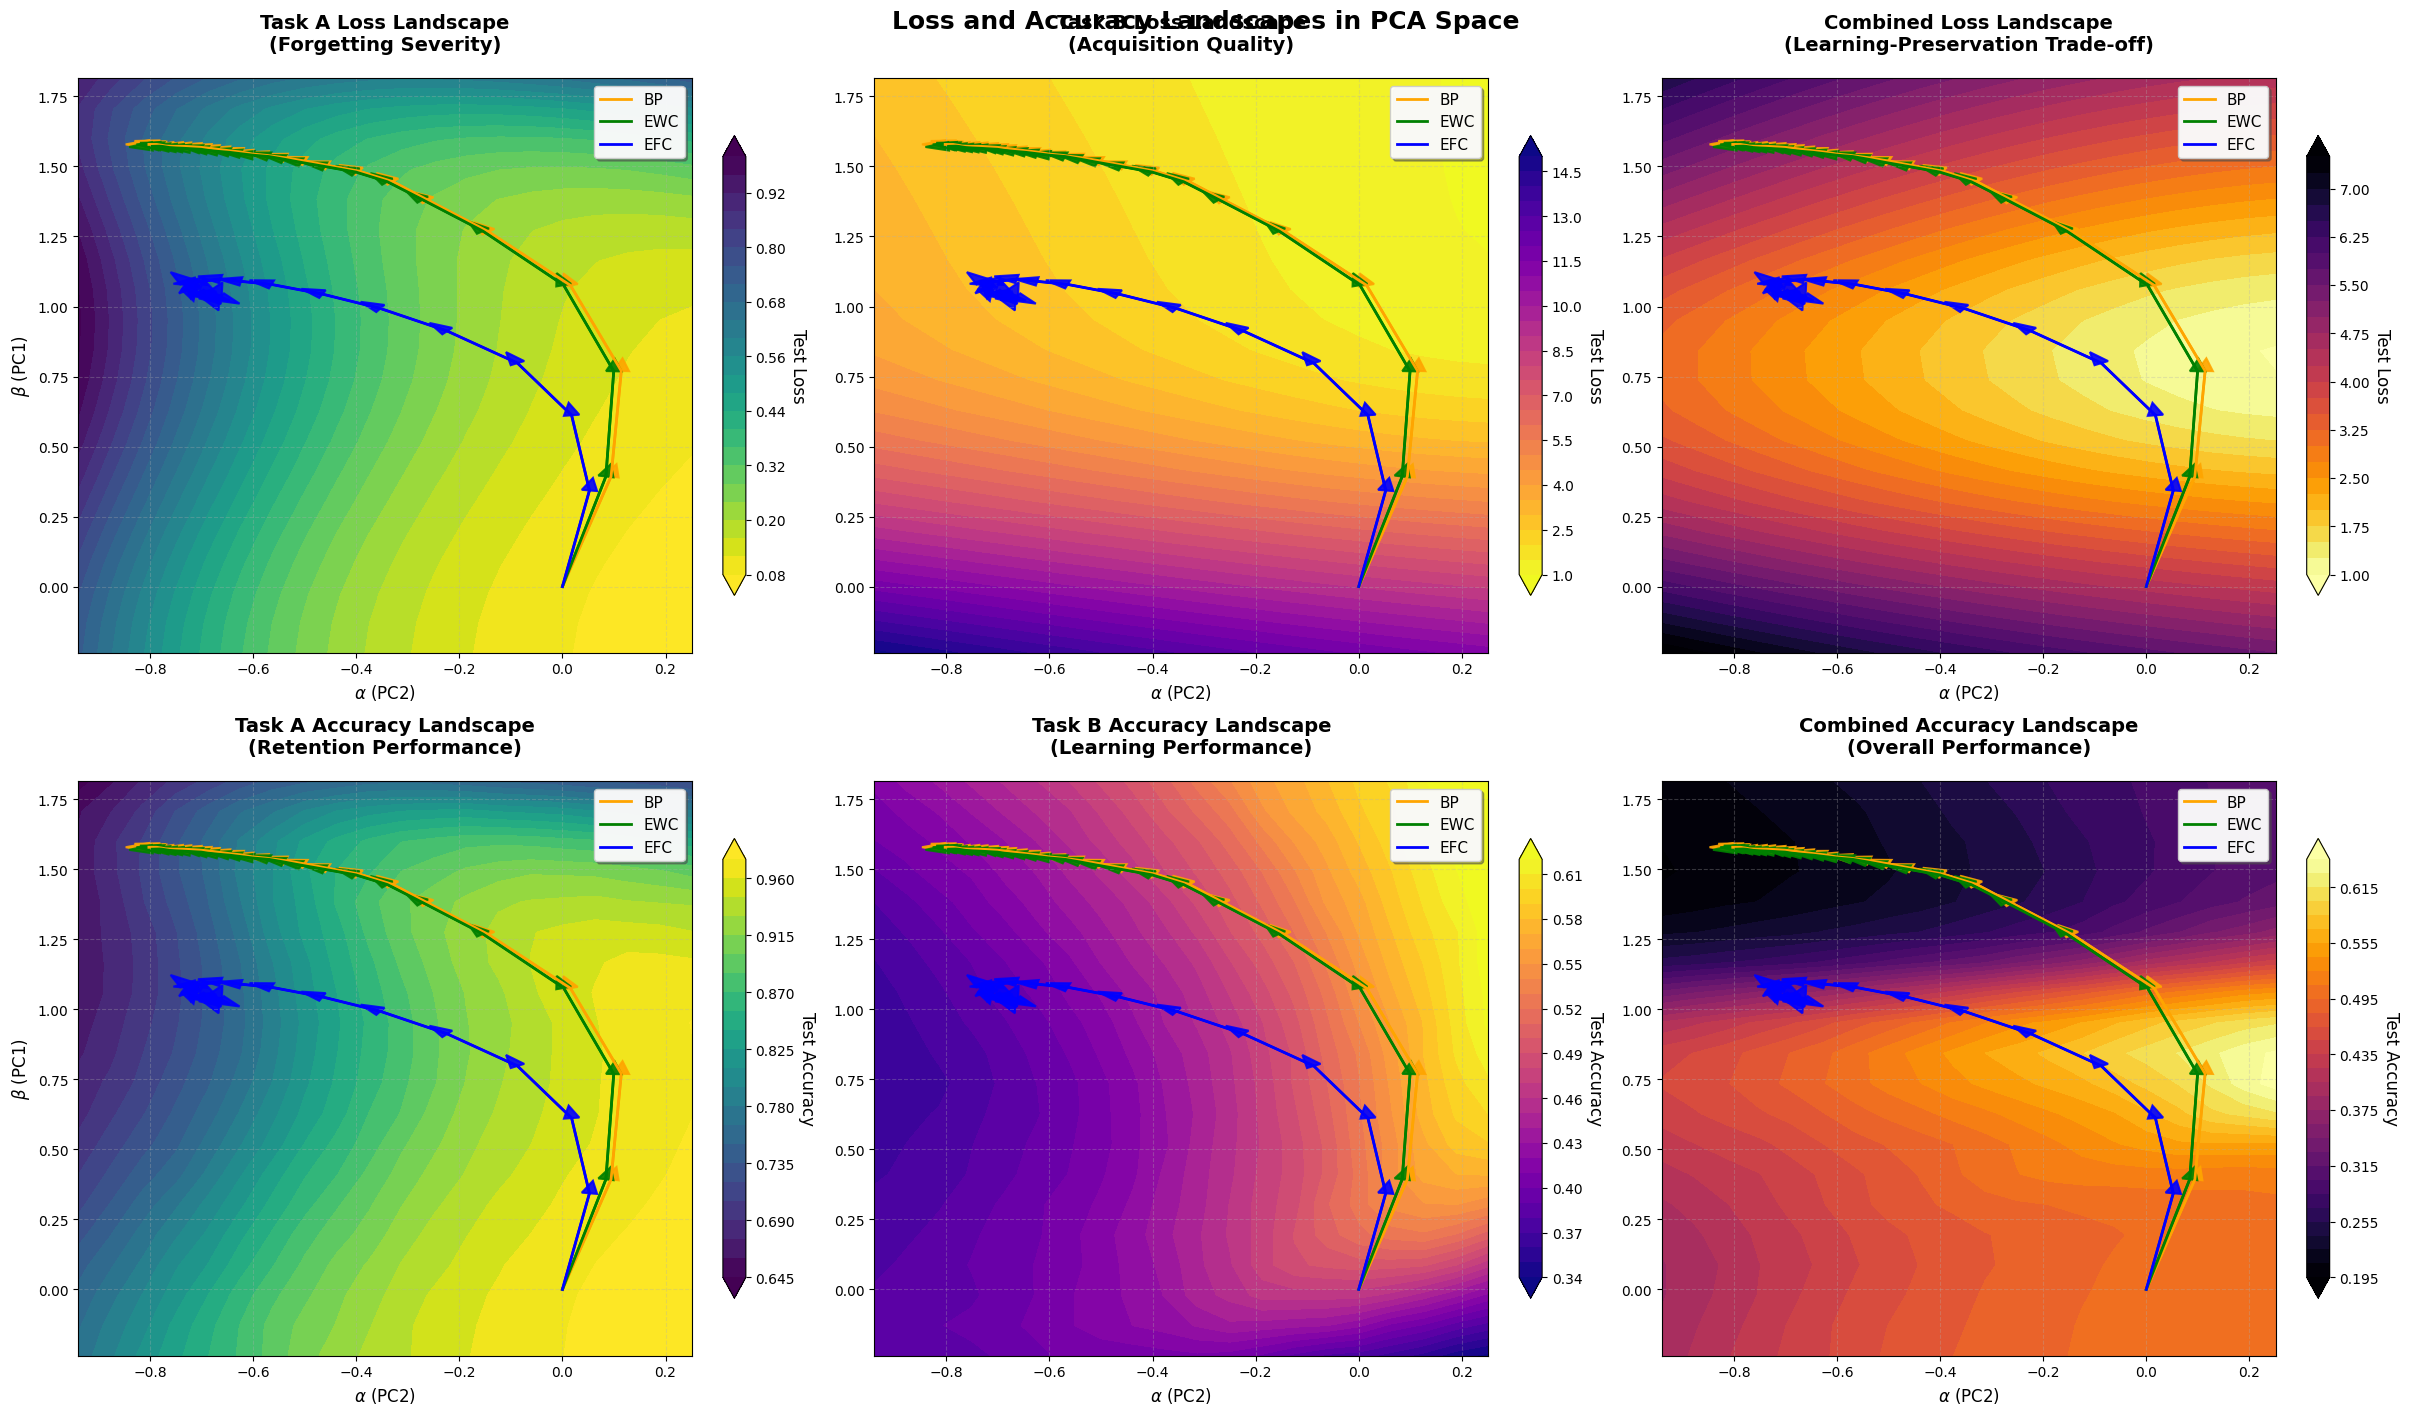

Variance explained by PC1: 0.625, PC2: 0.114


In [162]:
# === Plotting with 2 rows: Loss landscapes (top) and Accuracy landscapes (bottom) ===
fig, axs = plt.subplots(2, 3, figsize=(24, 14), constrained_layout=True)

# Reverse colormaps for loss: dark = low loss, light = high loss
# Regular colormaps for accuracy: dark = low acc, light = high acc
loss_cmaps = ['viridis_r', 'plasma_r', 'inferno_r']
acc_cmaps = ['viridis', 'plasma', 'inferno']  # NOT reversed for accuracy

titles_loss = [
    'Task A Loss Landscape\n(Forgetting Severity)',
    'Task B Loss Landscape\n(Acquisition Quality)',
    'Combined Loss Landscape\n(Learning-Preservation Trade-off)'
]

titles_acc = [
    'Task A Accuracy Landscape\n(Retention Performance)',
    'Task B Accuracy Landscape\n(Learning Performance)',
    'Combined Accuracy Landscape\n(Overall Performance)'
]

loss_matrices = [losses_A, losses_B, losses_combined]
acc_matrices = [accs_A, accs_B, accs_combined]

# Colors for trajectories
colors = {'bp': 'orange', 'ewc': 'green', 'efc': 'blue', 'ehc': 'red'}

def plot_trajectories(ax):
    for method in methods:
        x = traj_projections[method]['alpha']
        y = traj_projections[method]['beta']
        ax.plot(x, y, '-', color=colors[method], label=method.upper(), linewidth=2)
        for k in range(1, len(x)):
            ax.arrow(x[k-1], y[k-1], x[k]-x[k-1], y[k]-y[k-1],
                     color=colors[method], head_width=0.03, alpha=0.9, linewidth=1.5)

# Plot loss landscapes (top row)
for idx, (ax, loss_mat, cmap, title) in enumerate(zip(axs[0], loss_matrices, loss_cmaps, titles_loss)):
    levels = 30
    cont = ax.contourf(alpha, beta, loss_mat, levels=levels, cmap=cmap, extend='both')
    
    cbar = fig.colorbar(cont, ax=ax, shrink=0.8, aspect=20)
    cbar.set_label('Test Loss', rotation=270, labelpad=15, fontsize=12)

    plot_trajectories(ax)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel(r'$\alpha$ (PC2)', fontsize=12)
    if idx == 0:
        ax.set_ylabel(r'$\beta$ (PC1)', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, framealpha=0.95, fancybox=True, shadow=True)
    ax.set_xlim(alpha_range[0], alpha_range[1])
    ax.set_ylim(beta_range[0], beta_range[1])

# Plot accuracy landscapes (bottom row)
for idx, (ax, acc_mat, cmap, title) in enumerate(zip(axs[1], acc_matrices, acc_cmaps, titles_acc)):
    levels = 30
    cont = ax.contourf(alpha, beta, acc_mat, levels=levels, cmap=cmap, extend='both')
    
    cbar = fig.colorbar(cont, ax=ax, shrink=0.8, aspect=20)
    cbar.set_label('Test Accuracy', rotation=270, labelpad=15, fontsize=12)

    plot_trajectories(ax)

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel(r'$\alpha$ (PC2)', fontsize=12)
    if idx == 0:
        ax.set_ylabel(r'$\beta$ (PC1)', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, framealpha=0.95, fancybox=True, shadow=True)
    ax.set_xlim(alpha_range[0], alpha_range[1])
    ax.set_ylim(beta_range[0], beta_range[1])

plt.suptitle("Loss and Accuracy Landscapes in PCA Space", 
             fontsize=18, fontweight='bold', y=1.00)
plt.show()

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.3f}, PC2: {pca.explained_variance_ratio_[1]:.3f}")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


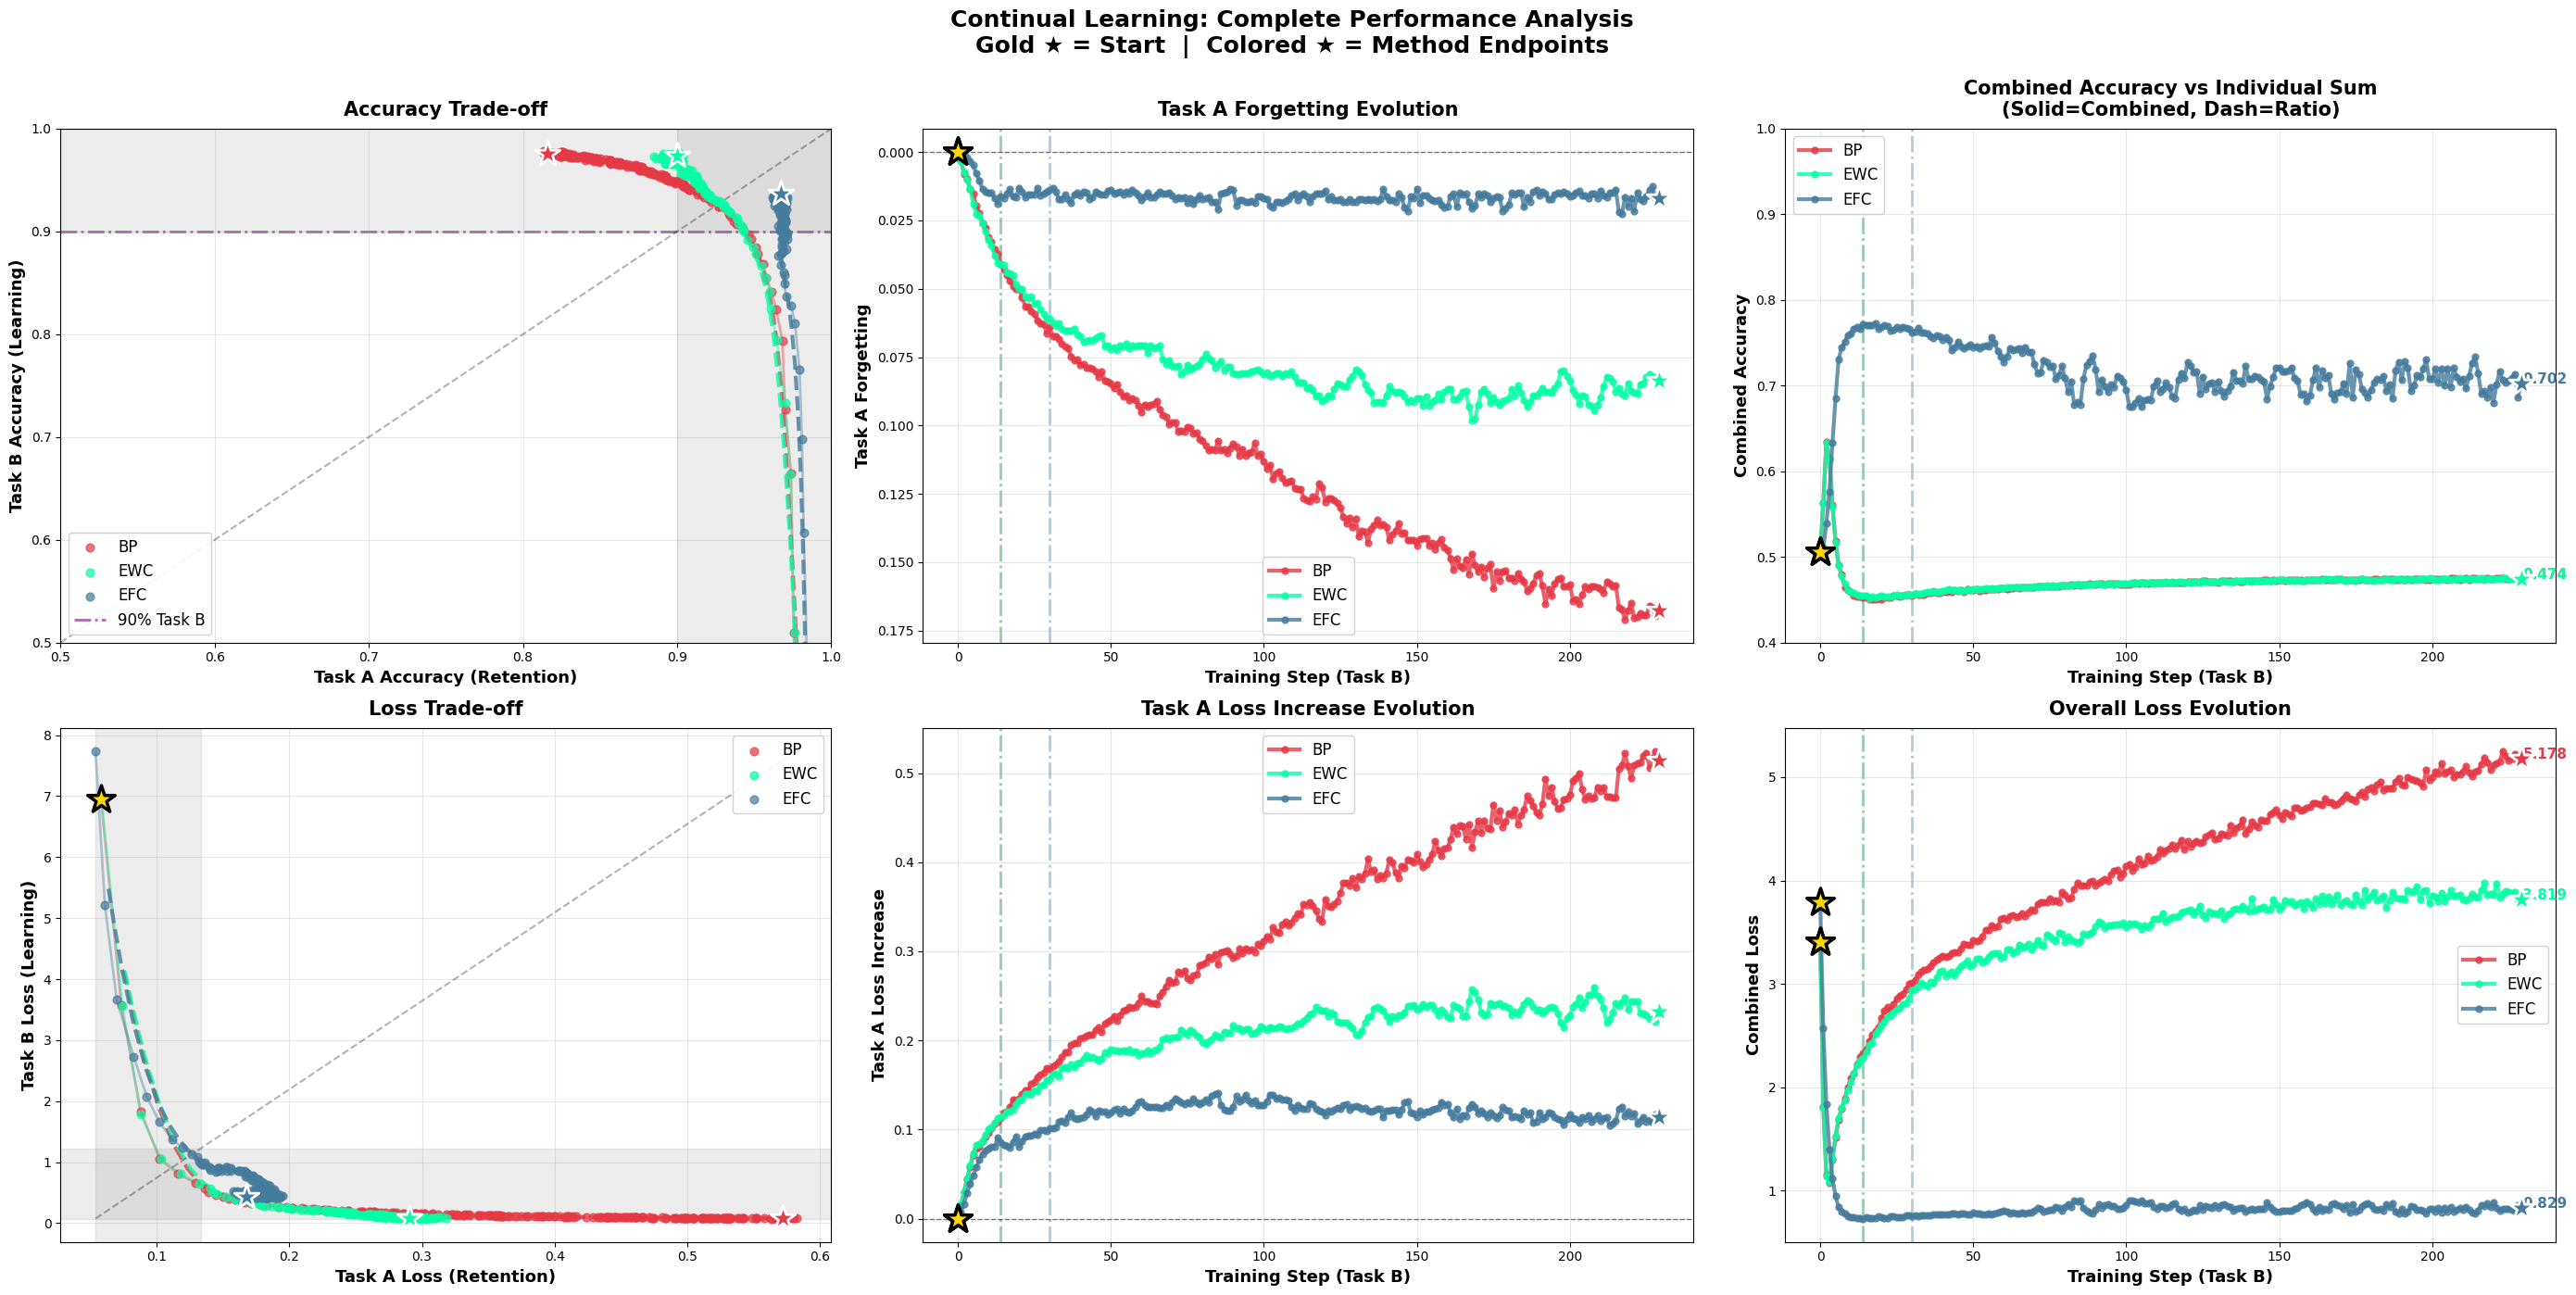


FINAL PERFORMANCE SUMMARY

BP:
  Task A Acc: 0.816 (Forgetting: 0.168)
  Combined Acc: 0.474
  Combined Loss: 5.178

EWC:
  Task A Acc: 0.900 (Forgetting: 0.083)
  Combined Acc: 0.474
  Combined Loss: 3.819

EFC:
  Task A Acc: 0.968 (Forgetting: 0.017)
  Combined Acc: 0.702
  Combined Loss: 0.829


In [195]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# Extract data from your logs
trajectory_acc = {}
trajectory_loss = {}
for method in methods:
    trajectory_acc[method] = {
        'acc_A': acc_logs[method]['acc_A'],
        'acc_B': acc_logs[method]['acc_B'],
        'acc_C': acc_logs[method]['combined']
    }
    trajectory_loss[method] = {
        'loss_A': loss_logs[method]['loss_A'],
        'loss_B': loss_logs[method]['loss_B'],
        'loss_C': loss_logs[method]['combined']
    }

task_b_90_timepoints = {}
for method in methods:
    acc_B = np.array(trajectory_acc[method]['acc_B'])
    idx = np.where(acc_B >= 0.9)[0]
    if len(idx) > 0:
        task_b_90_timepoints[method] = idx[0]  # First timepoint where acc_B >= 0.9
    else:
        task_b_90_timepoints[method] = None

# Create figure: 2 rows (accuracy/loss) × 3 columns
fig = plt.figure(figsize=(28, 14))

# More distinct colors
colors_method = {'bp': '#E63946', 'ewc': '#06FFA5', 'efc': '#457B9D'}  # Red, Bright cyan, Blue

# ============ PLOT 1: Task A vs Task B Accuracy Trade-off ============
ax1 = plt.subplot(2, 3, 1)

for method in methods:
    acc_A = np.array(trajectory_acc[method]['acc_A'])
    acc_B = np.array(trajectory_acc[method]['acc_B'])
    
    # Plot trajectory as simple line
    ax1.plot(acc_A, acc_B, '-', color=colors_method[method], 
            linewidth=2, alpha=0.4)
    
    # Scatter points (small dots)
    ax1.scatter(acc_A, acc_B, s=40, color=colors_method[method], 
               alpha=0.7, label=method.upper(), zorder=3)
    
    # Add smooth trendline
    if len(acc_A) > 3:
        acc_A_smooth = gaussian_filter1d(acc_A, sigma=2)
        acc_B_smooth = gaussian_filter1d(acc_B, sigma=2)
        ax1.plot(acc_A_smooth, acc_B_smooth, '--', color=colors_method[method], 
                linewidth=3, alpha=0.8, zorder=2)
    
    # Mark endpoint with star
    ax1.scatter(acc_A[-1], acc_B[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)

# Mark common starting point
acc_A_start = trajectory_acc['bp']['acc_A'][0]
acc_B_start = trajectory_acc['bp']['acc_B'][0]
ax1.scatter(acc_A_start, acc_B_start, s=500, marker='*', 
           color='gold', edgecolor='black', linewidth=2.5, zorder=6)

# Add grey "ideal region" shading (overlapping gives darker)
ax1.axhspan(0.9, 1.0, alpha=0.15, color='grey')
ax1.axvspan(0.9, 1.0, alpha=0.15, color='grey')

# Diagonal reference line (no label)
ax1.plot([0.5, 1], [0.5, 1], 'k--', alpha=0.3, linewidth=1.5)

ax1.axhline(y=0.9, color='purple', linestyle='-.', linewidth=2, alpha=0.6, label='90% Task B', zorder=1)

ax1.set_xlabel('Task A Accuracy (Retention)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Task B Accuracy (Learning)', fontsize=13, fontweight='bold')
ax1.set_title('Accuracy Trade-off', fontsize=15, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12, loc='lower left', framealpha=0.9)
ax1.set_xlim([0.5, 1.0])
ax1.set_ylim([0.5, 1.0])

# ============ PLOT 2: Task A Forgetting over Time (Accuracy) ============
ax2 = plt.subplot(2, 3, 2)

for method in methods:
    acc_A = np.array(trajectory_acc[method]['acc_A'])
    initial_acc_A = acc_A[0]
    forgetting = initial_acc_A - acc_A
    steps = np.arange(len(acc_A))
    
    # Mark starting point with star
    ax2.scatter(steps[0], forgetting[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    ax2.plot(steps, forgetting, '-o', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    # Mark endpoint with star
    ax2.scatter(steps[-1], forgetting[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    
for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax2.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Task A Forgetting', fontsize=13, fontweight='bold')
ax2.set_title('Task A Forgetting Evolution', fontsize=15, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12, loc='best', framealpha=0.9)
ax2.invert_yaxis()

# ============ PLOT 3: Combined Performance with Ratio Overlay ============
ax3 = plt.subplot(2, 3, 3)

for method in methods:
    acc_C = np.array(trajectory_acc[method]['acc_C'])
    acc_A = np.array(trajectory_acc[method]['acc_A'])
    acc_B = np.array(trajectory_acc[method]['acc_B'])
    steps = np.arange(len(acc_C))
    
    # Calculate ratio: combined / (acc_A + acc_B)
    ratio = acc_C / (acc_A + acc_B + 1e-10)
    
    # Mark starting point with star
    ax3.scatter(steps[0], acc_C[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    # Plot combined accuracy (solid line, left y-axis)
    ax3.plot(steps, acc_C, '-o', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    
    # Mark endpoint with star and value
    ax3.scatter(steps[-1], acc_C[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    ax3.text(steps[-1]+0.5, acc_C[-1], f'{acc_C[-1]:.3f}', 
            fontsize=11, fontweight='bold', color=colors_method[method])

for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax3.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)


ax3.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Combined Accuracy', fontsize=13, fontweight='bold', color='black')
ax3.set_title('Combined Accuracy vs Individual Sum\n(Solid=Combined, Dash=Ratio)', 
             fontsize=15, fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=12, loc='upper left', framealpha=0.9)
ax3.set_ylim([0.4, 1.0])


# ============ PLOT 4: Task A vs Task B Loss Trade-off ============
ax4 = plt.subplot(2, 3, 4)

for method in methods:
    loss_A = np.array(trajectory_loss[method]['loss_A'])
    loss_B = np.array(trajectory_loss[method]['loss_B'])
    
    # Plot trajectory
    ax4.plot(loss_A, loss_B, '-', color=colors_method[method], 
            linewidth=2, alpha=0.4)
    
    # Scatter points
    ax4.scatter(loss_A, loss_B, s=40, color=colors_method[method], 
               alpha=0.7, label=method.upper(), zorder=3)
    
    # Add smooth trendline
    if len(loss_A) > 3:
        loss_A_smooth = gaussian_filter1d(loss_A, sigma=2)
        loss_B_smooth = gaussian_filter1d(loss_B, sigma=2)
        ax4.plot(loss_A_smooth, loss_B_smooth, '--', color=colors_method[method], 
                linewidth=3, alpha=0.8, zorder=2)
    
    # Mark endpoint with star
    ax4.scatter(loss_A[-1], loss_B[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)

# Mark common starting point
loss_A_start = trajectory_loss['bp']['loss_A'][0]
loss_B_start = trajectory_loss['bp']['loss_B'][0]
ax4.scatter(loss_A_start, loss_B_start, s=500, marker='*', 
           color='gold', edgecolor='black', linewidth=2.5, zorder=6)

# Get reasonable axis limits
all_loss_A = np.concatenate([trajectory_loss[m]['loss_A'] for m in methods])
all_loss_B = np.concatenate([trajectory_loss[m]['loss_B'] for m in methods])
loss_A_min, loss_A_max = all_loss_A.min(), all_loss_A.max()
loss_B_min, loss_B_max = all_loss_B.min(), all_loss_B.max()

# Add grey "ideal region" shading (low loss = good, bottom-left corner)
ax4.axhspan(loss_B_min, loss_B_min + 0.15*(loss_B_max-loss_B_min), alpha=0.15, color='grey')
ax4.axvspan(loss_A_min, loss_A_min + 0.15*(loss_A_max-loss_A_min), alpha=0.15, color='grey')

# Diagonal reference line
ax4.plot([loss_A_min, loss_A_max], [loss_B_min, loss_B_max], 'k--', alpha=0.3, linewidth=1.5)

ax4.set_xlabel('Task A Loss (Retention)', fontsize=13, fontweight='bold')
ax4.set_ylabel('Task B Loss (Learning)', fontsize=13, fontweight='bold')
ax4.set_title('Loss Trade-off', fontsize=15, fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=12, loc='upper right', framealpha=0.9)

# ============ PLOT 5: Task A Loss Increase over Time ============
ax5 = plt.subplot(2, 3, 5)

for method in methods:
    loss_A = np.array(trajectory_loss[method]['loss_A'])
    initial_loss_A = loss_A[0]
    loss_increase = loss_A - initial_loss_A  # Increase = how much loss went up
    steps = np.arange(len(loss_A))
    
    # Mark starting point with star
    ax5.scatter(steps[0], loss_increase[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    ax5.plot(steps, loss_increase, '-o', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    # Mark endpoint with star
    ax5.scatter(steps[-1], loss_increase[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    
for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax5.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax5.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax5.set_ylabel('Task A Loss Increase', fontsize=13, fontweight='bold')
ax5.set_title('Task A Loss Increase Evolution', fontsize=15, fontweight='bold', pad=10)
ax5.grid(True, alpha=0.3)
ax5.legend(fontsize=12, loc='best', framealpha=0.9)

# ============ PLOT 6: Combined Loss over Time ============
ax6 = plt.subplot(2, 3, 6)

for method in methods:
    loss_C = np.array(trajectory_loss[method]['loss_C'])
    steps = np.arange(len(loss_C))
    
    # Mark starting point with star
    ax6.scatter(steps[0], loss_C[0], s=500, marker='*', 
               color='gold', edgecolor='black', linewidth=2.5, zorder=6)
    
    ax6.plot(steps, loss_C, '-o', color=colors_method[method], 
            linewidth=3, markersize=5, label=method.upper(), alpha=0.8)
    
    # Mark endpoint with star and value
    ax6.scatter(steps[-1], loss_C[-1], s=400, marker='*', 
               color=colors_method[method], edgecolor='white', linewidth=2, zorder=5)
    ax6.text(steps[-1]+0.5, loss_C[-1], f'{loss_C[-1]:.3f}', 
            fontsize=11, fontweight='bold', color=colors_method[method])
    
# Add vertical lines when Task B reaches 90%
for method in methods:
    if task_b_90_timepoints[method] is not None:
        ax6.axvline(x=task_b_90_timepoints[method], color=colors_method[method], 
                   linestyle='-.', linewidth=2, alpha=0.4, zorder=1)

ax6.set_xlabel('Training Step (Task B)', fontsize=13, fontweight='bold')
ax6.set_ylabel('Combined Loss', fontsize=13, fontweight='bold')
ax6.set_title('Overall Loss Evolution', fontsize=15, fontweight='bold', pad=10)
ax6.grid(True, alpha=0.3)
ax6.legend(fontsize=12, loc='best', framealpha=0.9)


plt.suptitle('Continual Learning: Complete Performance Analysis\nGold ★ = Start  |  Colored ★ = Method Endpoints', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('figs/performance_analysis.svg', format='svg', bbox_inches='tight')
plt.savefig('figs/performance_analysis.eps', format='eps', bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*70)
print("FINAL PERFORMANCE SUMMARY")
print("="*70)
for method in methods:
    acc_A_final = trajectory_acc[method]['acc_A'][-1]
    acc_A_initial = trajectory_acc[method]['acc_A'][0]
    forgetting = acc_A_initial - acc_A_final
    acc_C_final = trajectory_acc[method]['acc_C'][-1]
    loss_C_final = trajectory_loss[method]['loss_C'][-1]
    
    print(f"\n{method.upper()}:")
    print(f"  Task A Acc: {acc_A_final:.3f} (Forgetting: {forgetting:.3f})")
    print(f"  Combined Acc: {acc_C_final:.3f}")
    print(f"  Combined Loss: {loss_C_final:.3f}")

## (2) t-SNE Weight Update Projections

## (3) Eigenvalue Spectrum

Todo: Extract \tilde{F}_A from dynamics

In [ ]:
# This comparison visualizes matrix similarity via eigenvalue distributions (curvature scales) and quadratic forms (anisotropic shapes in subspaces). Compute eigenvalues for each matrix ($H_A$, $\tilde{F}_A$, $F_A^D$; note $F_A^D$ is diagonal, so its eigenvalues are its entries). Overlay spectra as line plots (sorted eigenvalues) to show overlap in magnitude/distribution—close curves mean similar curvatures. For deeper visual comparison, overlay 2D contours of quadratic approximations $\frac{1}{2} \delta^\top M \delta$ (where $M$ is each matrix) in a shared subspace (e.g., top-2 eigenvectors of $H_A$). This shows how each matrix's "bowl" shape aligns, with overlap as similar ellipse orientations/scales (validating $\tilde{F}_A \approx H_A > F_A^D$).
# Explicit Computation and Visualization:

# Eigenvalue Spectra: Compute sorted eigenvalues; plot as overlapping curves (x: eigenvalue index, y: value). Use log-scale if spectra span orders of magnitude.
# Quadratic Form Contours: Project into subspace spanned by top-2 eigenvectors $P$ of $H_A$ (columns of $P \in \mathbb{R}^{p \times 2}$). For grid $\delta = [\alpha, \beta]^\top$, compute $\frac{1}{2} (P \delta)^\top M (P \delta)$ for each $M$; contour-plot overlays.
# Tie to CL: Evaluate on $L_{A\&B}$ perturbations to link to forgetting.